In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_rows_w_zerovis.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_w_zerovis.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  HourlyWindDirection  \
0                         0.0            16.093                  0.0   
1                         0.0            16.093    

In [3]:
max_visibility = CV_rows["HourlyVisibility"].max()
min_visibility = CV_rows["HourlyVisibility"].min()
print("Maximum HourlyVisibility:", max_visibility)
print("Minimum HourlyVisibility:", min_visibility)

print("CV_rows:", CV_rows.shape)

Maximum HourlyVisibility: 16.093
Minimum HourlyVisibility: 0.0
CV_rows: (10821802, 14)


In [4]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (10429072, 14)


In [5]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)

CV_filtered_rows after removing April-October: (4526168, 14)


In [6]:
CV_filtered_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,0.0,16.093,0.0,0.0,1941,12,1,0,0,GARDNER AAF
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,0.0,16.093,158.0,0.5,1941,12,1,1,0,GARDNER AAF
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,0.0,16.093,0.0,0.0,1941,12,1,2,0,GARDNER AAF
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,0.0,16.093,225.0,0.5,1941,12,1,3,0,GARDNER AAF
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,0.0,16.093,225.0,0.5,1941,12,1,4,0,GARDNER AAF


In [7]:
# Build fog events from hourly fog rows and count "fog days" with noon-crossing adjustment
filtered_events = CV_filtered_rows.loc[:, ["STATION", "DATE"]].copy()
filtered_events["DATE"] = pd.to_datetime(filtered_events["DATE"], errors="coerce")
filtered_events = filtered_events.dropna(subset=["DATE"]).sort_values(["STATION", "DATE"])

# New event starts when time gap within station is > 1.5 hours (or first record)
gap = filtered_events.groupby("STATION")["DATE"].diff()
filtered_events["new_event"] = gap.isna() | gap.gt(pd.Timedelta(hours=2))
filtered_events["event_id"] = filtered_events.groupby("STATION")["new_event"].cumsum()

# Event start/end per station-event
event_summary = (
    filtered_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(start=("DATE", "min"), end=("DATE", "max"))
)

event_summary["start_date"] = event_summary["start"].dt.floor("D")
event_summary["end_date"] = event_summary["end"].dt.floor("D")
event_summary["calendar_days"] = (event_summary["end_date"] - event_summary["start_date"]).dt.days + 1

# Rule:
# - If event starts after 6pm and continues into next calendar day, count that first overnight span as 1 day
adjust_first_overnight = (
    (event_summary["start"].dt.hour > 18) &
    (event_summary["end_date"] > event_summary["start_date"])
).astype(int)

event_summary["counted_days"] = (event_summary["calendar_days"] - adjust_first_overnight).clip(lower=1).astype(int)

# Expand each event into counted day labels, then aggregate by station-year
expanded = event_summary.loc[event_summary.index.repeat(event_summary["counted_days"])].copy()
expanded["day_offset"] = expanded.groupby(level=0).cumcount()
expanded["fog_day"] = expanded["start_date"] + pd.to_timedelta(expanded["day_offset"], unit="D")
expanded["year"] = expanded["fog_day"].dt.year

fog_days_year_noon_rule = (
    expanded
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
    .sort_values(["STATION", "year"])
)

print(fog_days_year_noon_rule.head())
print("Rows:", fog_days_year_noon_rule.shape)

          STATION  year  fog_days
0  BAKERSFIELD AP  1928       168
1  BAKERSFIELD AP  1929       250
2  BAKERSFIELD AP  1930       100
3  BAKERSFIELD AP  1931       118
4  BAKERSFIELD AP  1932       153
Rows: (1278, 3)


In [8]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152


In [9]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


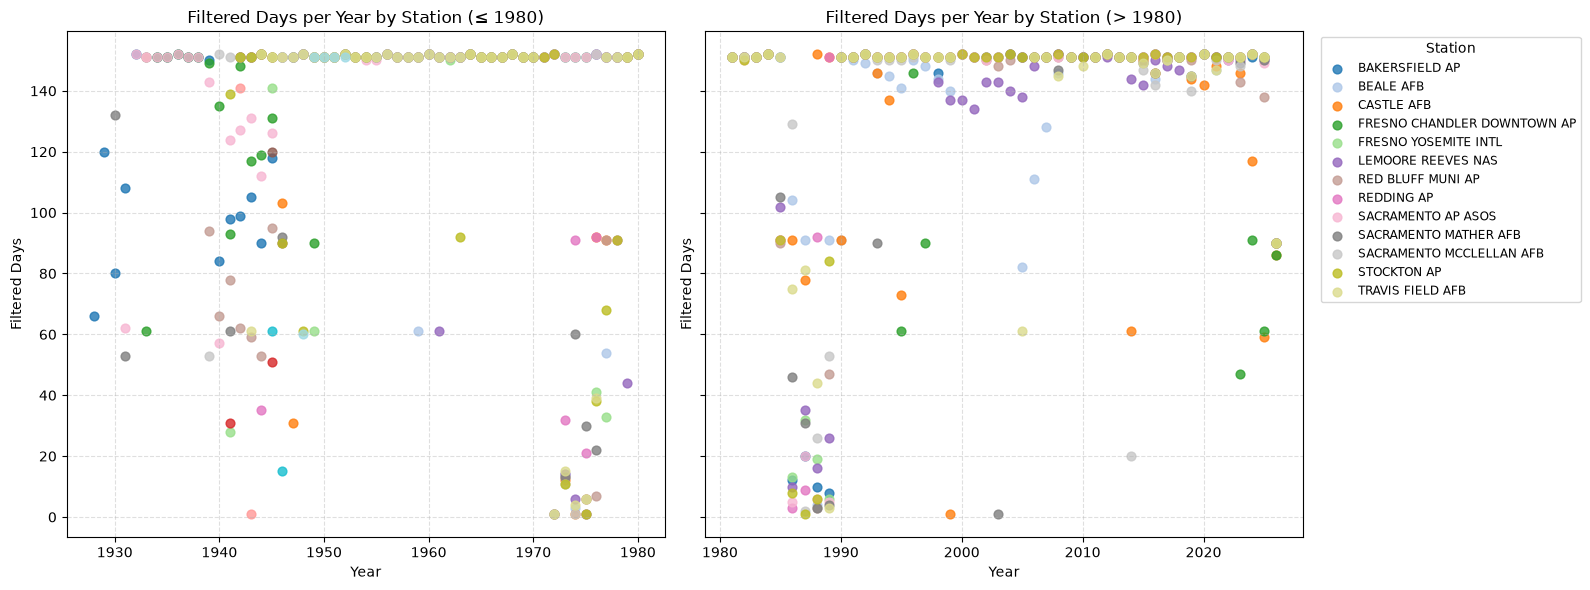

In [12]:
# plot the 'fog' days per year for the outliers for each station
# doing this in order to see where outlier years are
plot_stations = [st for st in stations_pre1970 if st in filtered_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

# Make sure to only plot for stations with data back to at least 1970
filtered_pre1970 = filtered_days_year[filtered_days_year['STATION'].isin(plot_stations)]

# Create a scatter plot for fog days per year for each station
# Data is separated into two subplots: one for years ≤ 1980 and another for years > 1980.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = filtered_pre1970[filtered_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['filtered_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['filtered_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Filtered Days per Year by Station (≤ 1980)')
axes[1].set_title('Filtered Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Filtered Days')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

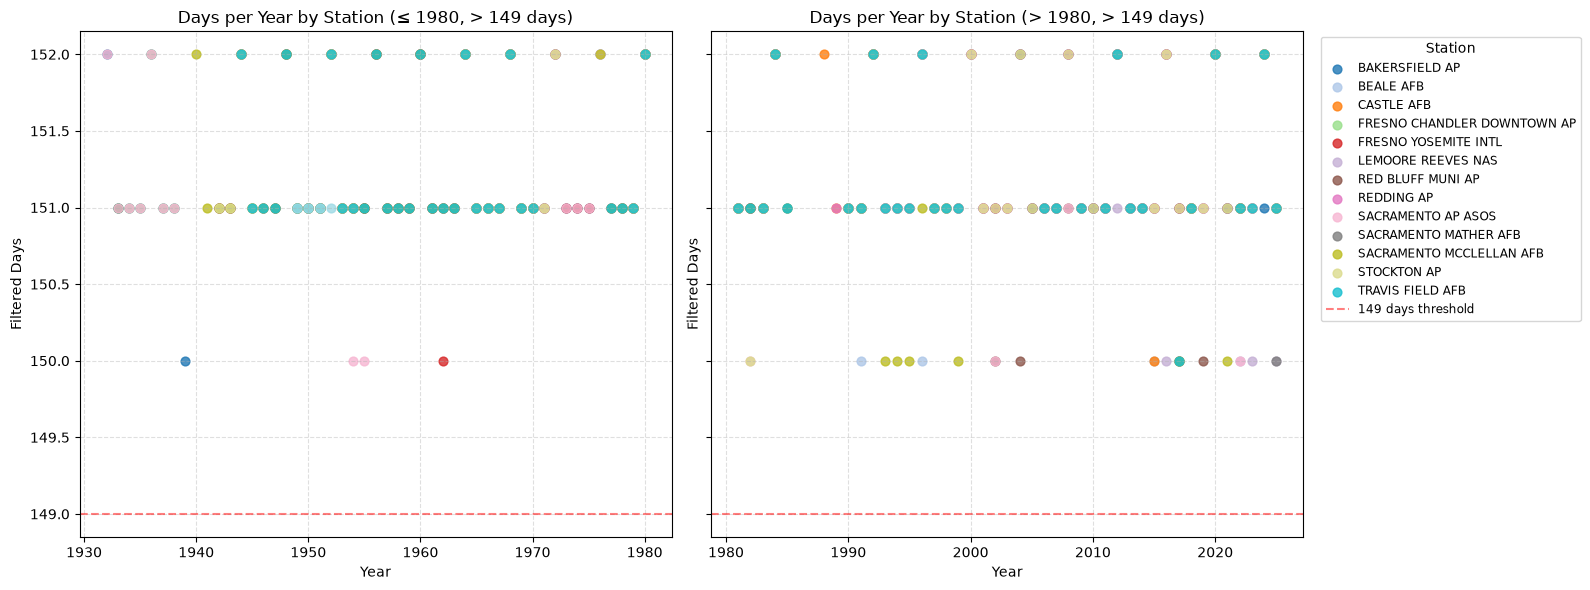

Stations with > 149 days: 16
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'WILLIAMS CAA AIRPORT']


In [13]:
# Remove stations with less than or only 200 days counted
filtered_days_year_filtered = filtered_days_year[filtered_days_year['filtered_days'] > 149]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in filtered_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1970 stations with > 355 fog days
filtered_pre1970_filtered = filtered_days_year_filtered[filtered_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = filtered_pre1970_filtered[filtered_pre1970_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['filtered_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['filtered_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Days per Year by Station (≤ 1980, > 149 days)')
axes[1].set_title('Days per Year by Station (> 1980, > 149 days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Filtered Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=149, color='red', linestyle='--', alpha=0.5, label='149 days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with > 149 days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [14]:
# Remove stations with 150 or fewer days counted
filtered_days_year_no_outliers = filtered_days_year[filtered_days_year["filtered_days"] > 150].copy()

# Get the valid station-year combinations for merging
valid_station_years = filtered_days_year_no_outliers[["STATION", "year"]]
CV_filtered_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", filtered_days_year_no_outliers.shape[0])
print("CV_filtered_rows_no_outliers:", CV_filtered_rows_no_outliers.shape)

Station-years kept: 918
CV_filtered_rows_no_outliers: (3630671, 14)


In [15]:
# Evaluate fog-day trends by visibility threshold for years >= 1980
p_cutoff = 0.05
thresholds = list(range(1, 26))

df_1980 = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

annual_by_threshold_1980 = {}
trend_rows_1980 = []

for threshold in thresholds:
    th_df = df_1980[df_1980["HourlyVisibility"] < threshold].copy()
    annual = (
        th_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "fog_days"})
        .sort_values(["STATION", "year"])
    )
    annual_by_threshold_1980[threshold] = annual

    for station, station_df in annual.groupby("STATION", sort=False):
        station_df = station_df.sort_values("year")
        if len(station_df) < 3:
            continue
        model = smf.ols("fog_days ~ year", data=station_df).fit()
        p_value = float(model.pvalues.get("year", np.nan))
        if np.isnan(p_value):
            continue
        trend_rows_1980.append({
            "threshold_km": threshold,
            "STATION": station,
            "n_obs": len(station_df),
            "min_year": int(station_df["year"].min()),
            "max_year": int(station_df["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": p_value,
            "trend_significant": p_value < p_cutoff,
        })

threshold_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values(["threshold_km", "p_value"])
significant_threshold_trends_1980 = threshold_trends_1980[threshold_trends_1980["trend_significant"]].copy()

print("Significant threshold-based fog-day trends since 1980 (p < 0.05):")
if significant_threshold_trends_1980.empty:
    print("None found.")
else:
    display_cols = ["threshold_km", "STATION", "n_obs", "slope", "p_value", "r_squared"]
    print(significant_threshold_trends_1980[display_cols].sort_values(["threshold_km", "p_value"]).to_string(index=False))

# # Optional: plot significant trendlines by threshold
# if not significant_threshold_trends_1980.empty:
#     thresholds_with_sig = sorted(significant_threshold_trends_1980["threshold_km"].unique())
#     fig, axes = plt.subplots(len(thresholds_with_sig), 1, figsize=(14, 2.8 * len(thresholds_with_sig)), sharex=True)
#     if len(thresholds_with_sig) == 1:
#         axes = [axes]
#     for ax, threshold in zip(axes, thresholds_with_sig):
#         th_df = significant_threshold_trends_1980[significant_threshold_trends_1980["threshold_km"] == threshold]
#         ax.set_title(f"Visibility < {threshold} km (significant trends since 1980)")
#         stations_for_threshold = th_df["STATION"].unique()
#         colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_threshold)))
#         cmap = dict(zip(stations_for_threshold, colors))
#         for station in stations_for_threshold:
#             row = th_df[th_df["STATION"] == station].iloc[0]
#             station_df = annual_by_threshold_1980[threshold][annual_by_threshold_1980[threshold]["STATION"] == station].sort_values("year")
#             if station_df.empty:
#                 continue
#             ax.scatter(station_df["year"], station_df["fog_days"], s=20, color=cmap[station], alpha=0.8)
#             x = np.arange(station_df["year"].min(), station_df["year"].max() + 1)
#             y_hat = row["intercept"] + row["slope"] * x
#             ax.plot(x, y_hat, color=cmap[station], linewidth=1.5, label=f"{station} (slope={row['slope']:.3f})")
#         ax.set_ylabel("Fog days / year")
#         ax.grid(True, linestyle="--", alpha=0.4)
#         ax.legend(fontsize="small", loc="best")
#     axes[-1].set_xlabel("Year")
#     plt.tight_layout()
#     plt.show()

Significant threshold-based fog-day trends since 1980 (p < 0.05):
 threshold_km                    STATION  n_obs     slope      p_value  r_squared
            1       FRESNO YOSEMITE INTL     41 -0.660703 1.679266e-07   0.508520
            1             BAKERSFIELD AP     41 -0.491368 4.469516e-07   0.483818
            1          RED BLUFF MUNI AP     35 -0.398781 2.060294e-05   0.427342
            1                STOCKTON AP     40 -0.365192 7.843350e-04   0.259640
            1  MARYSVILLE AIRPORT (ASOS)     16 -0.968735 1.716475e-03   0.516195
            1                  BEALE AFB     18 -0.311273 6.926468e-03   0.374757
            1       HANFORD MUNICIPAL AP     18 -1.088080 1.226091e-02   0.332387
            1 SACRAMENTO METROPOLITAN AP     37 -0.192138 2.893210e-02   0.129137
            1                 REDDING AP     42 -0.152769 3.458781e-02   0.106872
            2             BAKERSFIELD AP     41 -0.785603 8.996919e-10   0.622330
            2       FRESNO YOSEM

In [16]:
visibility = pd.to_numeric(CV_rows["HourlyVisibility"], errors="coerce")
mask_16_17 = visibility.gt(16.0) & visibility.lt(17.0)

vis_16_17_rows = CV_rows.loc[mask_16_17].copy()
print("Hourly rows with 16 < HourlyVisibility < 17 km:", len(vis_16_17_rows))

daily_vis_16_17 = (
    vis_16_17_rows
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "days_16_17"})
    .sort_values(["STATION", "year"])
)

annual_vis_16_17 = (
    daily_vis_16_17
    .groupby("year", as_index=False)["days_16_17"]
    .sum()
    .rename(columns={"days_16_17": "total_days_16_17"})
)

print("\nAnnual total station-days with 16-17 km visibility:")
print(annual_vis_16_17.head())

model_total_16_17 = smf.ols("total_days_16_17 ~ year", data=annual_vis_16_17).fit()
print("\nAnnual aggregated trend for 16-17 km visibility days:")
print(model_total_16_17.summary())

trend_rows_16_17 = []
for station, station_df in daily_vis_16_17.groupby("STATION", sort=False):
    station_df = station_df.sort_values("year")
    if len(station_df) < 10:
        continue

    model = smf.ols("days_16_17 ~ year", data=station_df).fit()
    p_value = float(model.pvalues.get("year", np.nan))

    trend_rows_16_17.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": int(station_df["year"].min()),
        "max_year": int(station_df["year"].max()),
        "slope": float(model.params.get("year", np.nan)),
        "intercept": float(model.params.get("Intercept", np.nan)),
        "r_squared": float(model.rsquared),
        "p_value": p_value,
        "trend_significant": p_value < 0.05,
    })

trend_vis_16_17 = pd.DataFrame(trend_rows_16_17).sort_values("p_value")
significant_vis_16_17 = trend_vis_16_17[trend_vis_16_17["trend_significant"]]

print("\nStation-level trends for 16-17 km visibility days (stations with ≥ 10 years):")
if significant_vis_16_17.empty:
    print("No significant station trends found.")
else:
    print(significant_vis_16_17[
        ["STATION", "n_obs", "min_year", "max_year", "slope", "p_value", "r_squared"]
    ].head(30).to_string(index=False))

Hourly rows with 16 < HourlyVisibility < 17 km: 6923414

Annual total station-days with 16-17 km visibility:
   year  total_days_16_17
0  1928                 1
1  1929               165
2  1930                 7
3  1931               384
4  1932               677

Annual aggregated trend for 16-17 km visibility days:
                            OLS Regression Results                            
Dep. Variable:       total_days_16_17   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     154.4
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           9.02e-22
Time:                        10:12:29   Log-Likelihood:                -861.12
No. Observations:                  99   AIC:                             1726.
Df Residuals:                      97   BIC:                             1731.
Df Model:                           1           

In [20]:
# # Evaluate fog-day trends by visibility threshold for years >= 1980
# p_cutoff = 0.05
# thresholds = list(range(1, 26))

# df_1980 = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

# annual_by_threshold_1980 = {}
# trend_rows_1980 = []

# for threshold in thresholds:
#     th_df = df_1980[df_1980["HourlyVisibility"] < threshold].copy()
#     annual = (
#         th_df
#         .drop_duplicates(subset=["STATION", "year", "month", "day"])
#         .groupby(["STATION", "year"], as_index=False)
#         .size()
#         .rename(columns={"size": "filtered_days"})
#         .sort_values(["STATION", "year"])
#     )
#     annual_by_threshold_1980[threshold] = annual

#     for station, station_df in annual.groupby("STATION", sort=False):
#         station_df = station_df.sort_values("year")
#         if len(station_df) < 3:
#             continue
#         model = smf.ols("filtered_days ~ year", data=station_df).fit()
#         p_value = float(model.pvalues.get("year", np.nan))
#         if np.isnan(p_value):
#             continue
#         trend_rows_1980.append({
#             "threshold_km": threshold,
#             "STATION": station,
#             "n_obs": len(station_df),
#             "min_year": int(station_df["year"].min()),
#             "max_year": int(station_df["year"].max()),
#             "slope": float(model.params.get("year", np.nan)),
#             "intercept": float(model.params.get("Intercept", np.nan)),
#             "r_squared": float(model.rsquared),
#             "p_value": p_value,
#             "trend_significant": p_value < p_cutoff,
#         })

# threshold_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values(["threshold_km", "p_value"])
# significant_threshold_trends_1980 = threshold_trends_1980[threshold_trends_1980["trend_significant"]].copy()

# print("Significant threshold-based fog-day trends since 1980 (p < 0.05):")
# if significant_threshold_trends_1980.empty:
#     print("None found.")
# else:
#     display_cols = ["threshold_km", "STATION", "n_obs", "slope", "p_value", "r_squared"]
#     print(significant_threshold_trends_1980[display_cols].sort_values(["threshold_km", "p_value"]).to_string(index=False))

# # Optional: plot significant trendlines by threshold
# if not significant_threshold_trends_1980.empty:
#     thresholds_with_sig = sorted(significant_threshold_trends_1980["threshold_km"].unique())
#     fig, axes = plt.subplots(len(thresholds_with_sig), 1, figsize=(14, 2.8 * len(thresholds_with_sig)), sharex=True)
#     if len(thresholds_with_sig) == 1:
#         axes = [axes]
#     for ax, threshold in zip(axes, thresholds_with_sig):
#         th_df = significant_threshold_trends_1980[significant_threshold_trends_1980["threshold_km"] == threshold]
#         ax.set_title(f"Visibility < {threshold} km (significant trends since 1980)")
#         stations_for_threshold = th_df["STATION"].unique()
#         colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_threshold)))
#         cmap = dict(zip(stations_for_threshold, colors))
#         for station in stations_for_threshold:
#             row = th_df[th_df["STATION"] == station].iloc[0]
#             station_df = annual_by_threshold_1980[threshold][annual_by_threshold_1980[threshold]["STATION"] == station].sort_values("year")
#             if station_df.empty:
#                 continue
#             ax.scatter(station_df["year"], station_df["filtered_days"], s=20, color=cmap[station], alpha=0.8)
#             x = np.arange(station_df["year"].min(), station_df["year"].max() + 1)
#             y_hat = row["intercept"] + row["slope"] * x
#             ax.plot(x, y_hat, color=cmap[station], linewidth=1.5, label=f"{station} (slope={row['slope']:.3f})")
#         ax.set_ylabel("Filtered days / year")
#         ax.grid(True, linestyle="--", alpha=0.4)
#         ax.legend(fontsize="small", loc="best")
#     axes[-1].set_xlabel("Year")
#     plt.tight_layout()
#     plt.show()

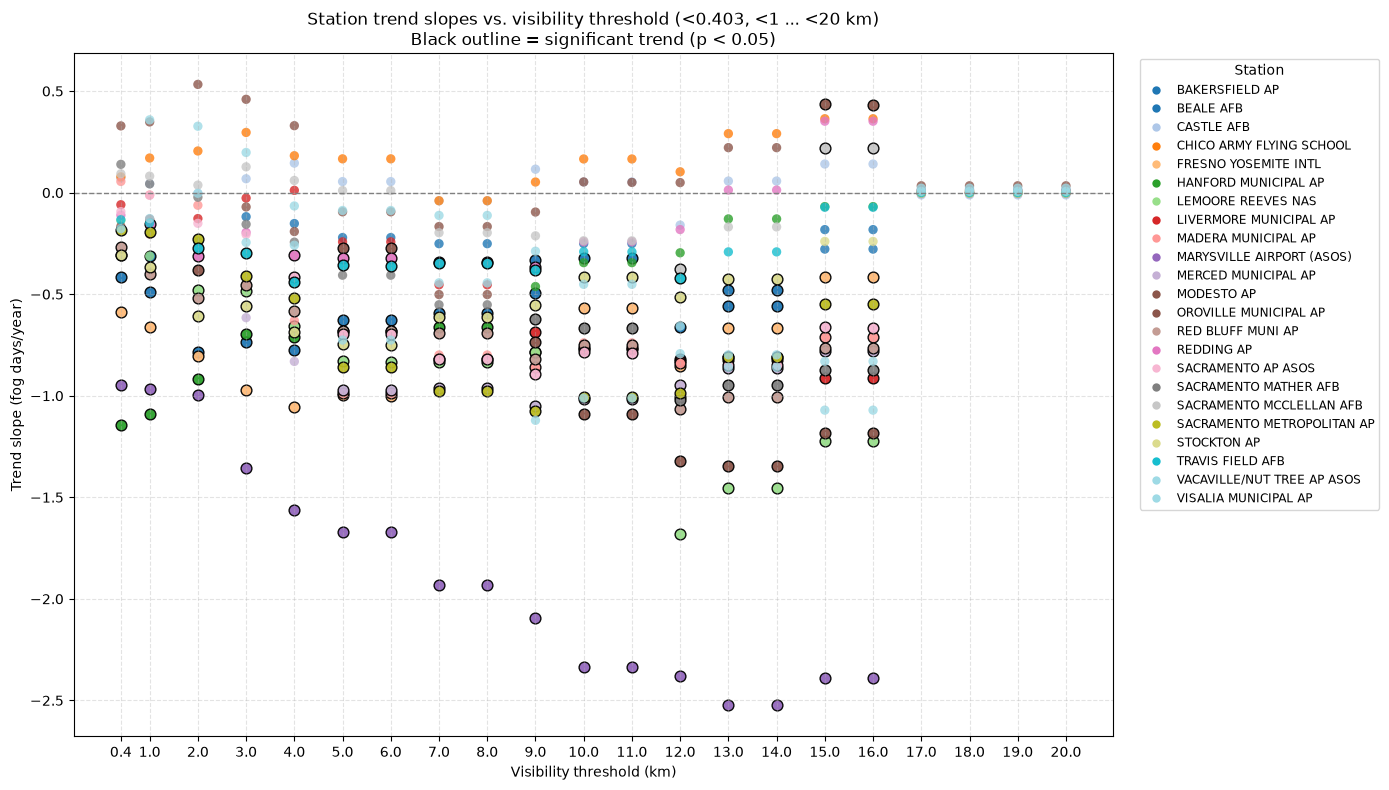

In [21]:
# Scatterplot of station trend slopes by visibility threshold:
# thresholds: <0.403 km, <1 km, <2 km, ... <20 km
# Uses existing trend_rows_1980 and computes <0.403 km trends to match that period (year >= 1980).

source_trend_rows = trend_rows_1980  # switch to trend_rows_2000 if you want post-2000 instead
trend_df = pd.DataFrame(source_trend_rows).copy()

# Keep integer thresholds from 1 to 20 km (inclusive) for plotting
trend_df = trend_df[trend_df["threshold_km"].between(1, 20)].copy()

# Build <0.403 km station trends (aligned to 1980+ window used above)
if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

th_0403_df = base_df[base_df["HourlyVisibility"] < 0.403].copy()
annual_0403 = (
    th_0403_df
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "filtered_days"})
    .sort_values(["STATION", "year"])
)

rows_0403 = []
for station, sdf in annual_0403.groupby("STATION", sort=False):
    sdf = sdf.sort_values("year")
    if len(sdf) < 10:
        continue
    model = smf.ols("filtered_days ~ year", data=sdf).fit()
    pval = float(model.pvalues.get("year", np.nan))
    if np.isnan(pval):
        continue
    rows_0403.append({
        "threshold_km": 0.403,
        "STATION": station,
        "n_obs": len(sdf),
        "min_year": int(sdf["year"].min()),
        "max_year": int(sdf["year"].max()),
        "slope": float(model.params.get("year", np.nan)),
        "intercept": float(model.params.get("Intercept", np.nan)),
        "r_squared": float(model.rsquared),
        "p_value": pval,
        "trend_significant": pval < 0.05,
    })

trend_0403 = pd.DataFrame(rows_0403)

# Combine
plot_df = pd.concat([trend_0403, trend_df], ignore_index=True)
plot_df = plot_df.sort_values(["STATION", "threshold_km"]).copy()

# Color map by station
stations = sorted(plot_df["STATION"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))
station_color = dict(zip(stations, colors))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

for st in stations:
    sdf = plot_df[plot_df["STATION"] == st]
    nonsig = sdf[~sdf["trend_significant"]]
    sig = sdf[sdf["trend_significant"]]

    # Non-significant points: station color, no black outline
    ax.scatter(
        nonsig["threshold_km"], nonsig["slope"],
        s=45, color=station_color[st], alpha=0.8, edgecolors="none"
    )

    # Significant points: station color + black outline
    ax.scatter(
        sig["threshold_km"], sig["slope"],
        s=60, color=station_color[st], alpha=0.95,
        edgecolors="black", linewidths=1.0
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Visibility threshold (km)")
ax.set_ylabel("Trend slope (fog days/year)")
ax.set_title("Station trend slopes vs. visibility threshold (<0.403, <1 ... <20 km)\nBlack outline = significant trend (p < 0.05)")
ax.set_xticks([0.403] + list(range(1, 21)))
ax.grid(True, linestyle="--", alpha=0.35)

# Legend (station colors)
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
               markerfacecolor=station_color[st], markeredgecolor="none", label=st)
    for st in stations
]
ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

plt.tight_layout()
plt.show()

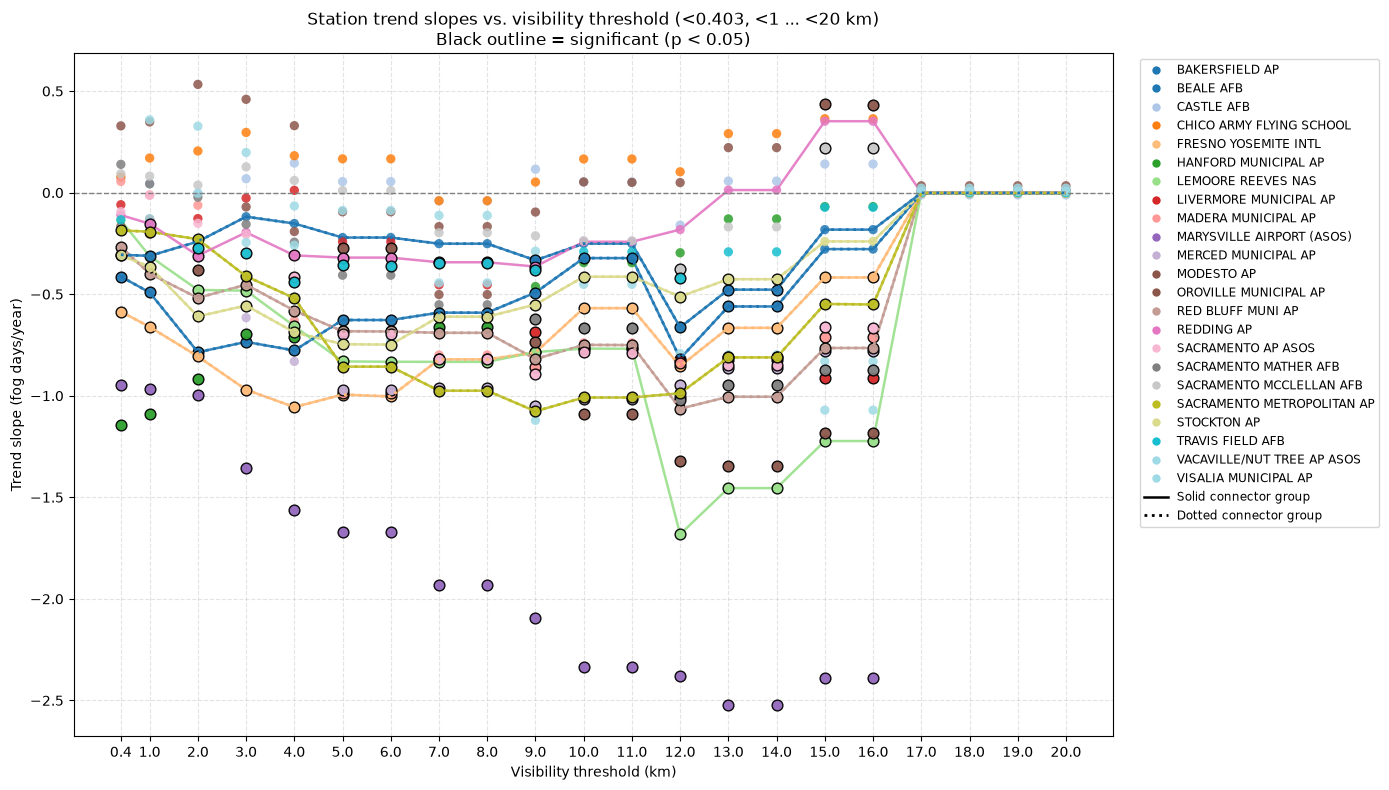

In [22]:
# Build slope-vs-threshold plot (1980+) with:
# - station-colored scatter points
# - black outline for significant trends
# - solid connector lines for one station set
# - dotted connector lines for another station set

# Base trends from existing list (1980+), keep thresholds 1..20
trend_df_1980 = pd.DataFrame(trend_rows_1980).copy()
trend_df_1980 = trend_df_1980[trend_df_1980["threshold_km"].between(1, 20)].copy()

# Compute <0.403 km trends for the same 1980+ window
if "df_1980" in globals():
    base_df_1980 = df_1980.copy()
else:
    base_df_1980 = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

th_0403_df = base_df_1980[base_df_1980["HourlyVisibility"] < 0.403].copy()
annual_0403 = (
    th_0403_df
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "filtered_days"})
    .sort_values(["STATION", "year"])
)

rows_0403 = []
for station, sdf in annual_0403.groupby("STATION", sort=False):
    sdf = sdf.sort_values("year")
    if len(sdf) < 10:
        continue
    model = smf.ols("filtered_days ~ year", data=sdf).fit()
    pval = float(model.pvalues.get("year", np.nan))
    if np.isnan(pval):
        continue
    rows_0403.append({
        "threshold_km": 0.403,
        "STATION": station,
        "n_obs": len(sdf),
        "min_year": int(sdf["year"].min()),
        "max_year": int(sdf["year"].max()),
        "slope": float(model.params.get("year", np.nan)),
        "intercept": float(model.params.get("Intercept", np.nan)),
        "r_squared": float(model.rsquared),
        "p_value": pval,
        "trend_significant": pval < 0.05,
    })

trend_0403 = pd.DataFrame(rows_0403)

# Combine for plotting
plot_df = pd.concat([trend_0403, trend_df_1980], ignore_index=True)
plot_df = plot_df.sort_values(["STATION", "threshold_km"]).copy()

# Station colors
stations = sorted(plot_df["STATION"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))
station_color = dict(zip(stations, colors))

# Line-connection station groups
solid_stations = [
    "FRESNO YOSEMITE INTL", "BAKERSFIELD AP", "RED BLUFF MUNI AP", "STOCKTON AP",
    "BEALE AFB", "LEMOORE REEVES NAS", "SACRAMENTO METROPOLITAN AP", "REDDING AP"
]
dotted_stations = [
    "FRESNO YOSEMITE INTL", "BAKERSFIELD AP", "RED BLUFF MUNI AP",
    "STOCKTON AP", "BEALE AFB", "SACRAMENTO METROPOLITAN AP"
]

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter points by station (outlined if significant)
for st in stations:
    sdf = plot_df[plot_df["STATION"] == st]
    nonsig = sdf[~sdf["trend_significant"]]
    sig = sdf[sdf["trend_significant"]]

    ax.scatter(
        nonsig["threshold_km"], nonsig["slope"],
        s=45, color=station_color[st], alpha=0.85, edgecolors="none", zorder=2
    )
    ax.scatter(
        sig["threshold_km"], sig["slope"],
        s=60, color=station_color[st], alpha=0.95,
        edgecolors="black", linewidths=1.0, zorder=3
    )

# Solid connectors
for st in solid_stations:
    sdf = plot_df[plot_df["STATION"] == st].sort_values("threshold_km")
    if sdf.empty:
        continue
    ax.plot(
        sdf["threshold_km"], sdf["slope"],
        linestyle="-", linewidth=1.8, color=station_color.get(st, "gray"),
        alpha=0.9, zorder=1
    )

# Dotted connectors
for st in dotted_stations:
    sdf = plot_df[plot_df["STATION"] == st].sort_values("threshold_km")
    if sdf.empty:
        continue
    ax.plot(
        sdf["threshold_km"], sdf["slope"],
        linestyle=":", linewidth=2.0, color=station_color.get(st, "gray"),
        alpha=1.0, zorder=4
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Visibility threshold (km)")
ax.set_ylabel("Trend slope (fog days/year)")
ax.set_title(
    "Station trend slopes vs. visibility threshold (<0.403, <1 ... <20 km)\n"
    "Black outline = significant (p < 0.05)"
)
ax.set_xticks([0.403] + list(range(1, 21)))
ax.grid(True, linestyle="--", alpha=0.35)

# Legend for stations (color)
station_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
               markerfacecolor=station_color[st], markeredgecolor="none", label=st)
    for st in stations
]
# Legend for line styles
style_handles = [
    plt.Line2D([0], [0], color="black", linestyle="-", linewidth=1.8, label="Solid connector group"),
    plt.Line2D([0], [0], color="black", linestyle=":", linewidth=2.0, label="Dotted connector group"),
]
ax.legend(handles=station_handles + style_handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

plt.tight_layout()
plt.show()

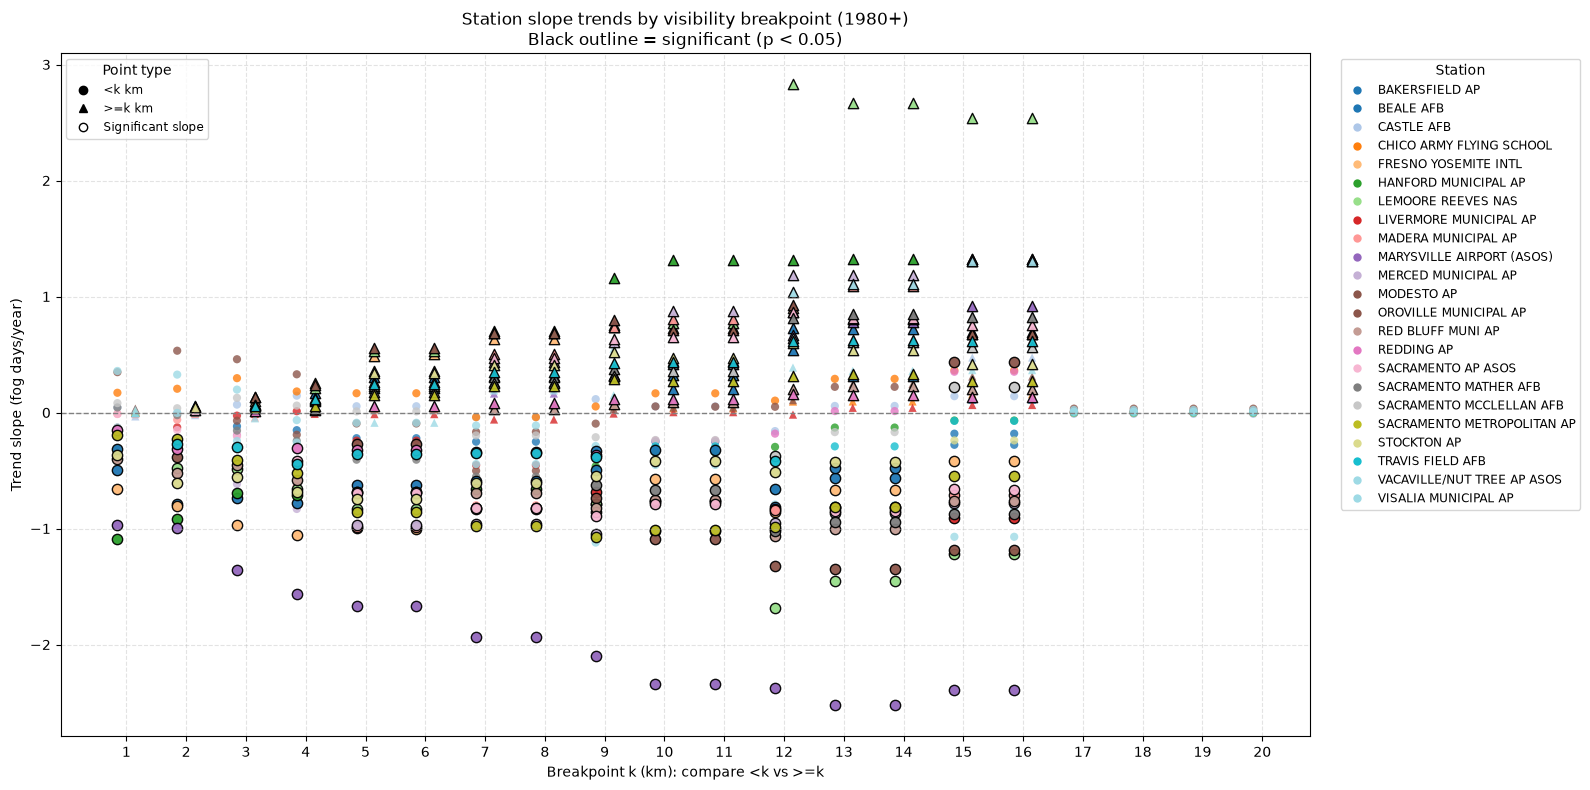

In [23]:
# Scatterplot of station trend slopes by breakpoint:
# (<k km) vs (>=k km), for k = 1..20, using 1980+ period.

breakpoints = list(range(1, 21))
p_cutoff = 0.05

# Base data window aligned with trend_rows_1980 logic
if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

# Use existing <k trends from trend_rows_1980
lt_df = pd.DataFrame(trend_rows_1980).copy()
lt_df = lt_df[lt_df["threshold_km"].isin(breakpoints)].copy()
lt_df["group"] = "lt"  # <k

# Compute >=k trends
ge_rows = []
for k in breakpoints:
    ge_k = base_df[base_df["HourlyVisibility"] >= k].copy()
    annual_ge = (
        ge_k
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "filtered_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual_ge.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue

        model = smf.ols("filtered_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue

        ge_rows.append({
            "threshold_km": k,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
            "group": "ge",  # >=k
        })

ge_df = pd.DataFrame(ge_rows)

# Combine
plot_df = pd.concat([lt_df, ge_df], ignore_index=True)

# Station colors
stations = sorted(plot_df["STATION"].dropna().unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))
station_color = dict(zip(stations, colors))

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
x_offset = {"lt": -0.15, "ge": 0.15}
marker_map = {"lt": "o", "ge": "^"}
label_map = {"lt": "<k km", "ge": ">=k km"}

for grp in ["lt", "ge"]:
    gdf = plot_df[plot_df["group"] == grp].copy()
    gdf["xpos"] = gdf["threshold_km"] + x_offset[grp]

    # Non-significant
    nonsig = gdf[~gdf["trend_significant"]]
    for st, sdf in nonsig.groupby("STATION"):
        ax.scatter(
            sdf["xpos"], sdf["slope"],
            s=35, marker=marker_map[grp],
            color=station_color[st], alpha=0.8, edgecolors="none"
        )

    # Significant (black outline)
    sig = gdf[gdf["trend_significant"]]
    for st, sdf in sig.groupby("STATION"):
        ax.scatter(
            sdf["xpos"], sdf["slope"],
            s=55, marker=marker_map[grp],
            color=station_color[st], alpha=0.95,
            edgecolors="black", linewidths=1.0
        )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(breakpoints)
ax.set_xlabel("Breakpoint k (km): compare <k vs >=k")
ax.set_ylabel("Trend slope (fog days/year)")
ax.set_title("Station slope trends by visibility breakpoint (1980+)\nBlack outline = significant (p < 0.05)")
ax.grid(True, linestyle="--", alpha=0.35)

# Legends
group_handles = [
    plt.Line2D([0], [0], marker=marker_map["lt"], linestyle="", color="black", label=label_map["lt"]),
    plt.Line2D([0], [0], marker=marker_map["ge"], linestyle="", color="black", label=label_map["ge"]),
    plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor="white", markeredgecolor="black",
               label="Significant slope")
]
station_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
               markerfacecolor=station_color[st], markeredgecolor="none", label=st)
    for st in stations
]

legend1 = ax.legend(handles=group_handles, loc="upper left", fontsize="small", title="Point type")
ax.add_artist(legend1)
ax.legend(handles=station_handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small", title="Station")

plt.tight_layout()
plt.show()

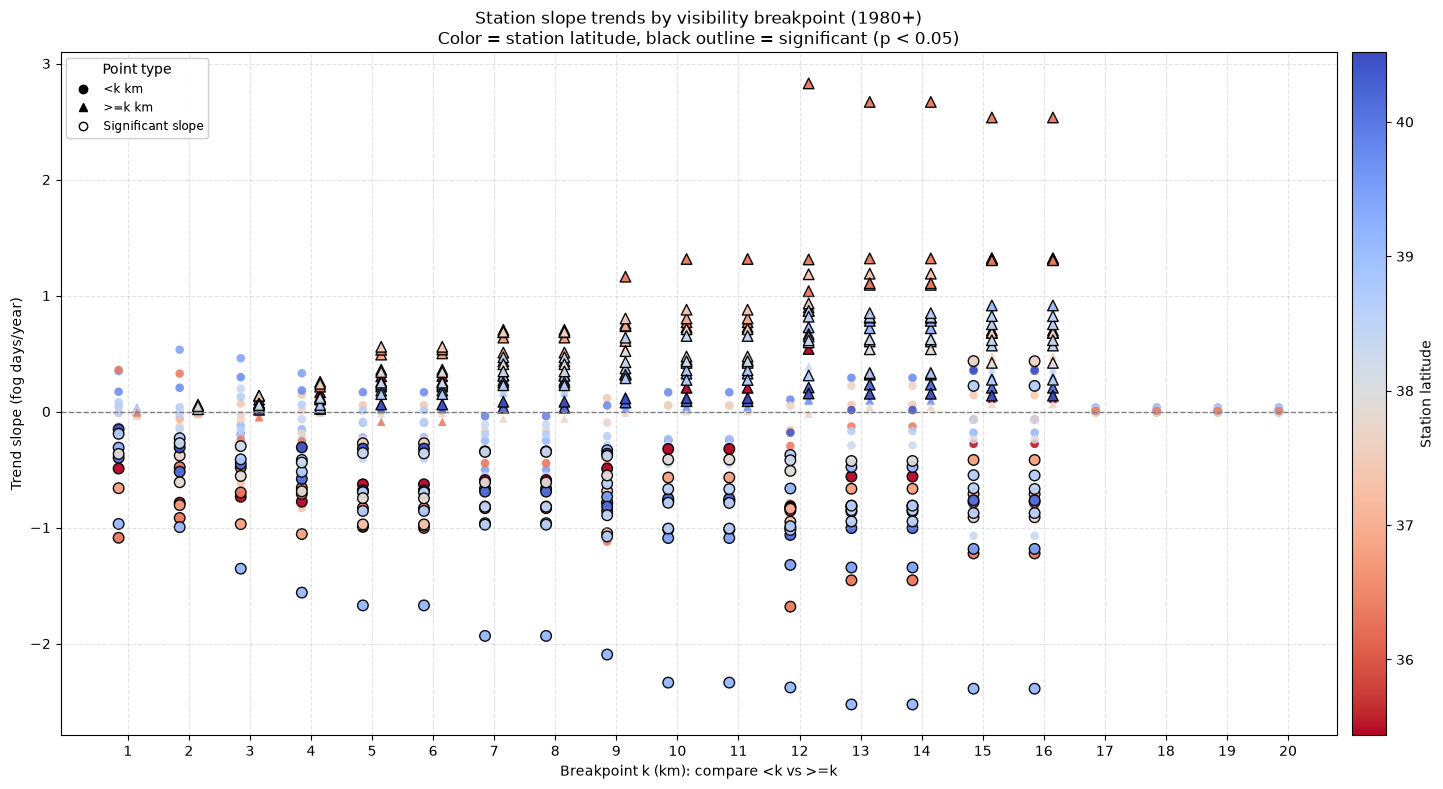

In [24]:
# Same breakpoint plot (<k vs >=k, 1980+) but color stations by latitude

breakpoints = list(range(1, 21))
p_cutoff = 0.05

# Base 1980+ data
if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

# Station latitude lookup
station_lat = (
    CV_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)

# <k trends from existing results
lt_df = pd.DataFrame(trend_rows_1980).copy()
lt_df = lt_df[lt_df["threshold_km"].isin(breakpoints)].copy()
lt_df["group"] = "lt"

# >=k trends
ge_rows = []
for k in breakpoints:
    ge_k = base_df[base_df["HourlyVisibility"] >= k].copy()
    annual_ge = (
        ge_k
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "filtered_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual_ge.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue

        model = smf.ols("filtered_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue

        ge_rows.append({
            "threshold_km": k,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
            "group": "ge",
        })

ge_df = pd.DataFrame(ge_rows)

# Combine and attach latitude
plot_df = pd.concat([lt_df, ge_df], ignore_index=True)
plot_df = plot_df.merge(station_lat, on="STATION", how="left").dropna(subset=["latitude"]).copy()

# Colormap by latitude
lat_min, lat_max = plot_df["latitude"].min(), plot_df["latitude"].max()
norm = plt.Normalize(lat_min, lat_max)
cmap = plt.cm.coolwarm_r # cool is blue (higher lat), warm is red (lower lat)

# Plot style
x_offset = {"lt": -0.15, "ge": 0.15}
marker_map = {"lt": "o", "ge": "^"}

fig, ax = plt.subplots(figsize=(16, 8))

for grp in ["lt", "ge"]:
    gdf = plot_df[plot_df["group"] == grp].copy()
    gdf["xpos"] = gdf["threshold_km"] + x_offset[grp]
    colors = cmap(norm(gdf["latitude"]))

    nonsig = gdf[~gdf["trend_significant"]]
    ax.scatter(
        nonsig["xpos"], nonsig["slope"],
        c=cmap(norm(nonsig["latitude"])),
        s=38, marker=marker_map[grp], alpha=0.85, edgecolors="none"
    )

    sig = gdf[gdf["trend_significant"]]
    ax.scatter(
        sig["xpos"], sig["slope"],
        c=cmap(norm(sig["latitude"])),
        s=58, marker=marker_map[grp], alpha=0.95,
        edgecolors="black", linewidths=1.0
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(breakpoints)
ax.set_xlabel("Breakpoint k (km): compare <k vs >=k")
ax.set_ylabel("Trend slope (fog days/year)")
ax.set_title("Station slope trends by visibility breakpoint (1980+)\nColor = station latitude, black outline = significant (p < 0.05)")
ax.grid(True, linestyle="--", alpha=0.35)

# Legends
group_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color="black", label="<k km"),
    plt.Line2D([0], [0], marker="^", linestyle="", color="black", label=">=k km"),
    plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor="white", markeredgecolor="black", label="Significant slope")
]
legend1 = ax.legend(handles=group_handles, loc="upper left", fontsize="small", title="Point type")
ax.add_artist(legend1)

smappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
smappable.set_array([])
cbar = plt.colorbar(smappable, ax=ax, pad=0.01)
cbar.set_label("Station latitude")

plt.tight_layout()
plt.show()

In [25]:
visibility = pd.to_numeric(CV_rows["HourlyVisibility"], errors="coerce")
vis_gt_17_rows = CV_rows.loc[visibility > 17.0].copy()

print("Rows with HourlyVisibility > 17 km:", len(vis_gt_17_rows))
vis_gt_17_rows.head()

Rows with HourlyVisibility > 17 km: 0


,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION


c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Work Account\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


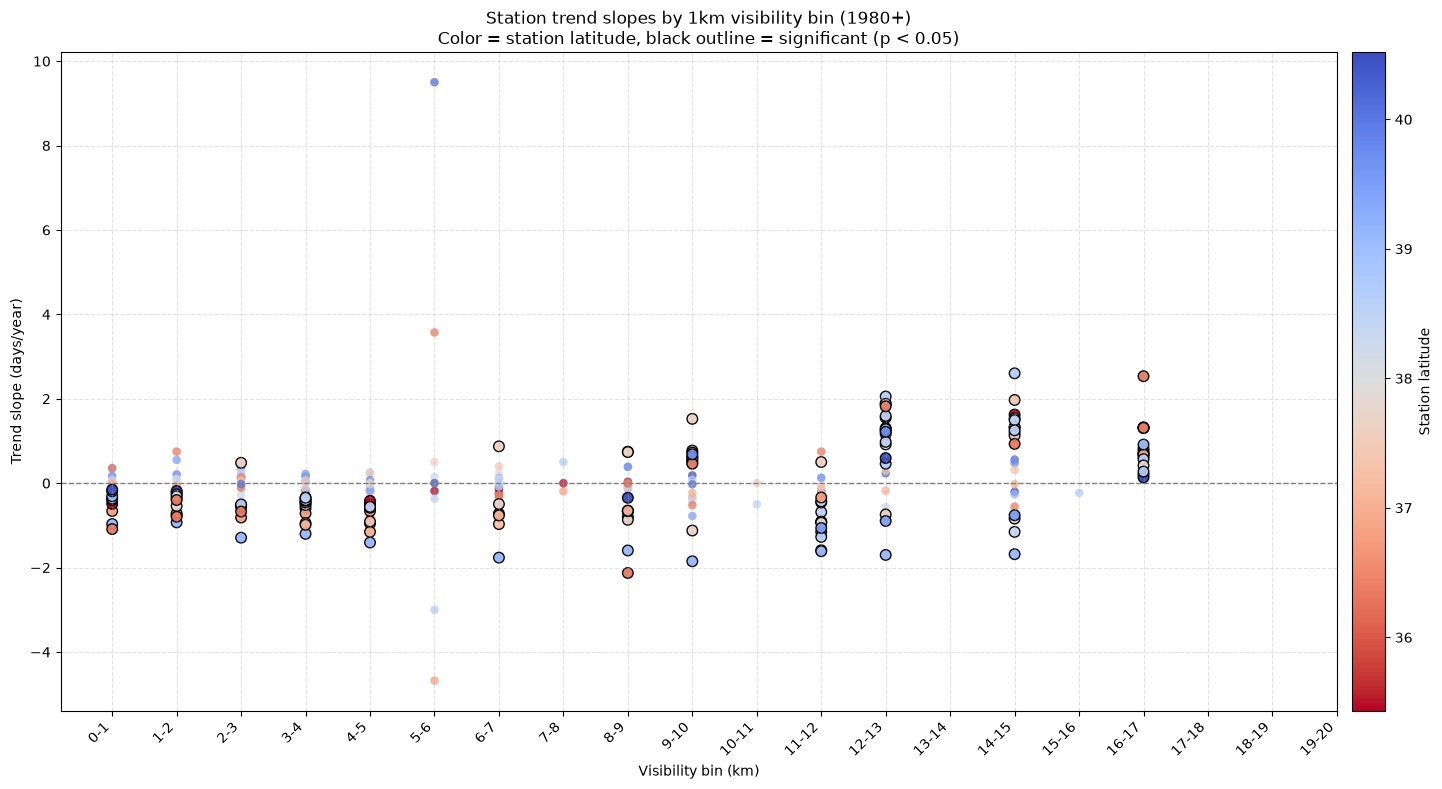


Significant trends: 142 / 291
bin_label                    STATION  n_obs     slope      p_value  r_squared
    0-1km       FRESNO YOSEMITE INTL     41 -0.660703 1.679266e-07   0.508520
    0-1km             BAKERSFIELD AP     41 -0.491368 4.469516e-07   0.483818
    0-1km          RED BLUFF MUNI AP     35 -0.398781 2.060294e-05   0.427342
    0-1km                STOCKTON AP     40 -0.365192 7.843350e-04   0.259640
    0-1km  MARYSVILLE AIRPORT (ASOS)     16 -0.968735 1.716475e-03   0.516195
    0-1km                  BEALE AFB     18 -0.311273 6.926468e-03   0.374757
    0-1km       HANFORD MUNICIPAL AP     18 -1.088080 1.226091e-02   0.332387
    0-1km SACRAMENTO METROPOLITAN AP     37 -0.192138 2.893210e-02   0.129137
    0-1km                 REDDING AP     42 -0.152769 3.458781e-02   0.106872
    1-2km             BAKERSFIELD AP     41 -0.755470 3.599797e-10   0.639428
    1-2km       FRESNO YOSEMITE INTL     41 -0.718949 1.556878e-07   0.510381
    1-2km                STOCKTON

In [26]:
# Analyze trends in 1km HourlyVisibility bins (1-2km, 2-3km, ..., 19-20km) for 1980+
p_cutoff = 0.05
bins = [(i, i+1) for i in range(0, 20)]

if "df_1980" not in globals():
    df_1980 = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

bin_trend_rows = []

for lo, hi in bins:
    bin_df = df_1980[
        (df_1980["HourlyVisibility"] >= lo) & (df_1980["HourlyVisibility"] < hi)
    ].copy()

    annual = (
        bin_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "fog_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue
        model = smf.ols("fog_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue
        bin_trend_rows.append({
            "bin_label": f"{lo}-{hi}km",
            "bin_lo": lo,
            "bin_mid": lo + 0.5,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
        })

bin_trends = pd.DataFrame(bin_trend_rows).sort_values(["bin_lo", "p_value"])

# Attach latitude for coloring
station_lat = (
    CV_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)
bin_trends = bin_trends.merge(station_lat, on="STATION", how="left").dropna(subset=["latitude"])

# Plot
lat_min, lat_max = bin_trends["latitude"].min(), bin_trends["latitude"].max()
norm = plt.Normalize(lat_min, lat_max)
cmap = plt.cm.coolwarm_r

fig, ax = plt.subplots(figsize=(16, 8))

nonsig = bin_trends[~bin_trends["trend_significant"]]
sig = bin_trends[bin_trends["trend_significant"]]

ax.scatter(
    nonsig["bin_mid"], nonsig["slope"],
    c=cmap(norm(nonsig["latitude"])),
    s=38, marker="o", alpha=0.75, edgecolors="none"
)
ax.scatter(
    sig["bin_mid"], sig["slope"],
    c=cmap(norm(sig["latitude"])),
    s=58, marker="o", alpha=0.95,
    edgecolors="black", linewidths=1.0
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks([b + 0.5 for b in range(0, 20)])
ax.set_xticklabels([f"{lo}-{lo+1}" for lo in range(0, 20)], rotation=45, ha="right")
ax.set_xlabel("Visibility bin (km)")
ax.set_ylabel("Trend slope (days/year)")
ax.set_title(
    "Station trend slopes by 1km visibility bin (1980+)\n"
    "Color = station latitude, black outline = significant (p < 0.05)"
)
ax.grid(True, linestyle="--", alpha=0.35)

smappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
smappable.set_array([])
cbar = plt.colorbar(smappable, ax=ax, pad=0.01)
cbar.set_label("Station latitude")

plt.tight_layout()
plt.show()

print(f"\nSignificant trends: {bin_trends['trend_significant'].sum()} / {len(bin_trends)}")
print(bin_trends[bin_trends["trend_significant"]][
    ["bin_label", "STATION", "n_obs", "slope", "p_value", "r_squared"]
].sort_values(["bin_label", "p_value"]).to_string(index=False))

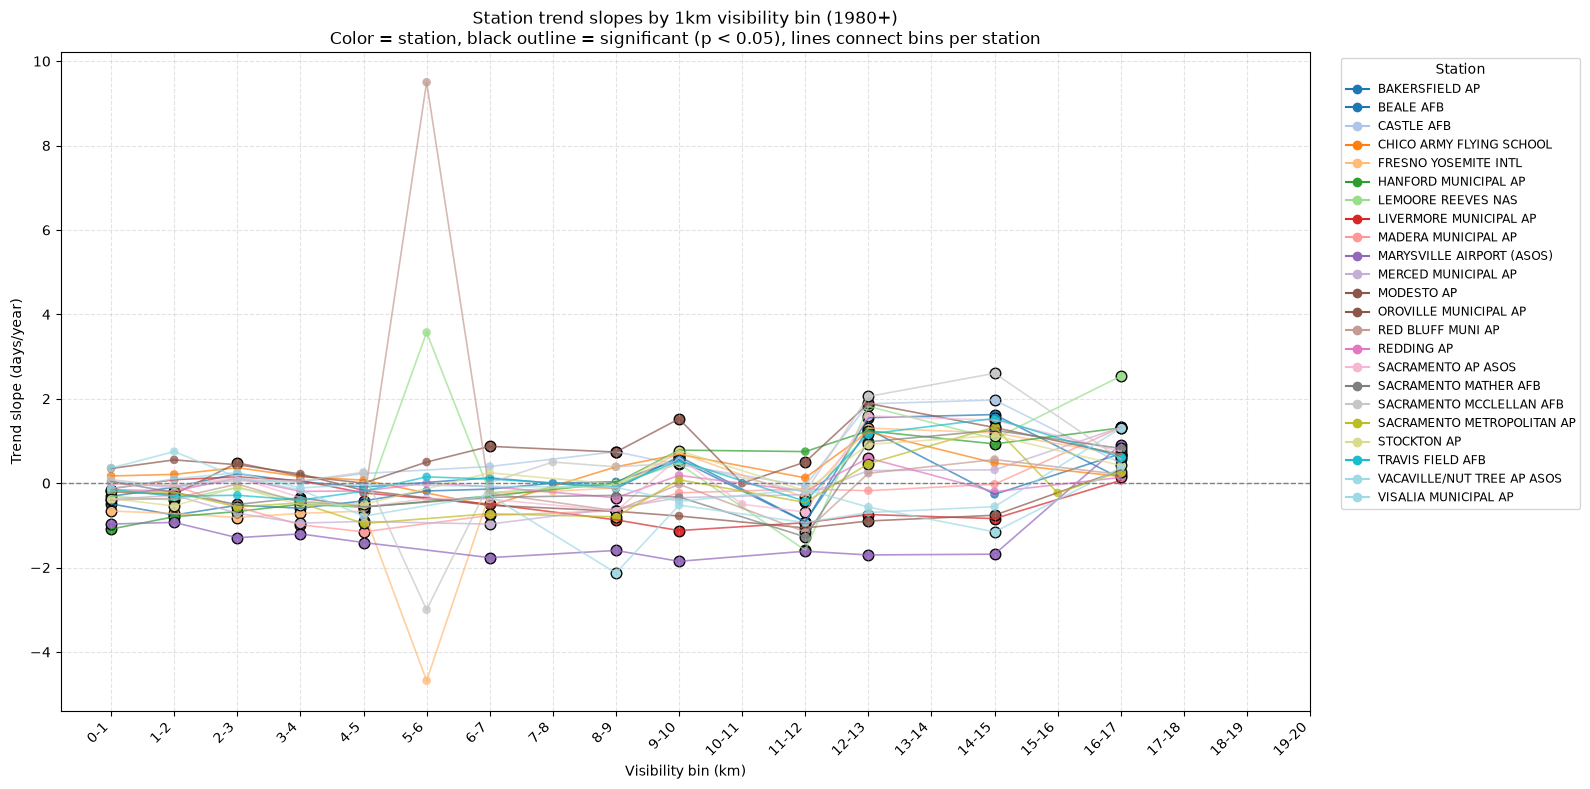

In [27]:
# Same 1km visibility bin trend plot but with unique station colors and connected lines

# Attach latitude for reference (already computed in bin_trends from cell 24)
station_lat = (
    CV_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)

bin_trends_colored = bin_trends.copy()

# Station color map
stations_in_plot = sorted(bin_trends_colored["STATION"].dropna().unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(stations_in_plot)))
station_color = dict(zip(stations_in_plot, colors))

fig, ax = plt.subplots(figsize=(16, 8))

for st in stations_in_plot:
    sdf = bin_trends_colored[bin_trends_colored["STATION"] == st].sort_values("bin_mid")
    if sdf.empty:
        continue

    color = station_color[st]

    # Connect points with a line
    ax.plot(sdf["bin_mid"], sdf["slope"], color=color, linewidth=1.2, alpha=0.7)

    # Non-significant points
    nonsig = sdf[~sdf["trend_significant"]]
    ax.scatter(nonsig["bin_mid"], nonsig["slope"],
               s=38, color=color, alpha=0.8, edgecolors="none")

    # Significant points: black outline
    sig = sdf[sdf["trend_significant"]]
    ax.scatter(sig["bin_mid"], sig["slope"],
               s=58, color=color, alpha=0.95,
               edgecolors="black", linewidths=1.0)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks([b + 0.5 for b in range(0, 20)])
ax.set_xticklabels([f"{lo}-{lo+1}" for lo in range(0, 20)], rotation=45, ha="right")
ax.set_xlabel("Visibility bin (km)")
ax.set_ylabel("Trend slope (days/year)")
ax.set_title(
    "Station trend slopes by 1km visibility bin (1980+)\n"
    "Color = station, black outline = significant (p < 0.05), lines connect bins per station"
)
ax.grid(True, linestyle="--", alpha=0.35)

# Station color legend
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="-", markersize=6,
               color=station_color[st], label=st)
    for st in stations_in_plot
]
ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1),
          loc="upper left", fontsize="small")

plt.tight_layout()
plt.show()

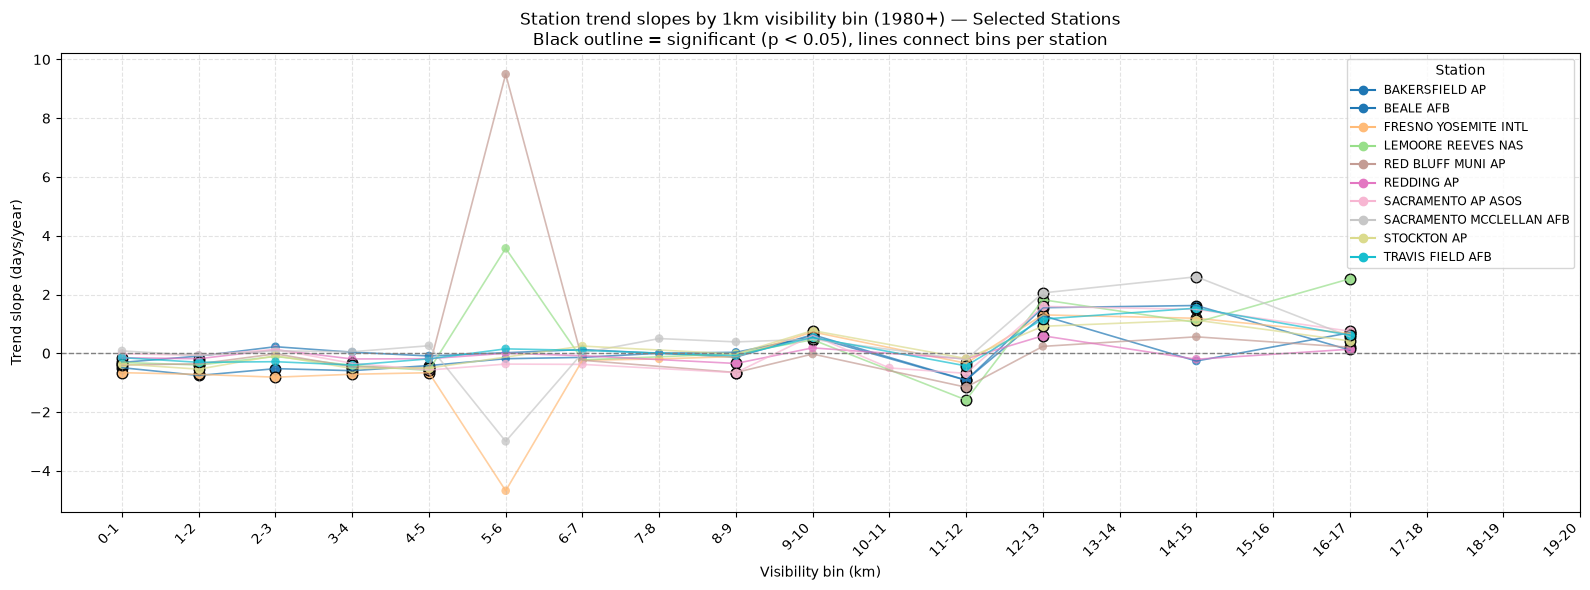

In [29]:
# Same 1km visibility bin trend plot but filtered to only BAKERSFIELD AP and BEALE AFB

selected_stations = ['BAKERSFIELD AP', 'BEALE AFB', 'FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB']
bin_trends_subset = bin_trends_colored[bin_trends_colored['STATION'].isin(selected_stations)].copy()

station_color_subset = {st: station_color[st] for st in selected_stations if st in station_color}

fig, ax = plt.subplots(figsize=(16, 6))

for st in selected_stations:
    sdf = bin_trends_subset[bin_trends_subset['STATION'] == st].sort_values('bin_mid')
    if sdf.empty:
        continue

    color = station_color_subset[st]
    ax.plot(sdf['bin_mid'], sdf['slope'], color=color, linewidth=1.2, alpha=0.7)

    nonsig = sdf[~sdf['trend_significant']]
    ax.scatter(nonsig['bin_mid'], nonsig['slope'],
               s=38, color=color, alpha=0.8, edgecolors='none')

    sig = sdf[sdf['trend_significant']]
    ax.scatter(sig['bin_mid'], sig['slope'],
               s=58, color=color, alpha=0.95,
               edgecolors='black', linewidths=1.0)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks([b + 0.5 for b in range(0, 20)])
ax.set_xticklabels([f'{lo}-{lo+1}' for lo in range(0, 20)], rotation=45, ha='right')
ax.set_xlabel('Visibility bin (km)')
ax.set_ylabel('Trend slope (days/year)')
ax.set_title(
    'Station trend slopes by 1km visibility bin (1980+) — Selected Stations\n'
    'Black outline = significant (p < 0.05), lines connect bins per station'
)
ax.grid(True, linestyle='--', alpha=0.35)

handles = [
    plt.Line2D([0], [0], marker='o', linestyle='-', markersize=6,
               color=station_color_subset[st], label=st)
    for st in selected_stations
]
ax.legend(handles=handles, title='Station', fontsize='small')

plt.tight_layout()
plt.show()

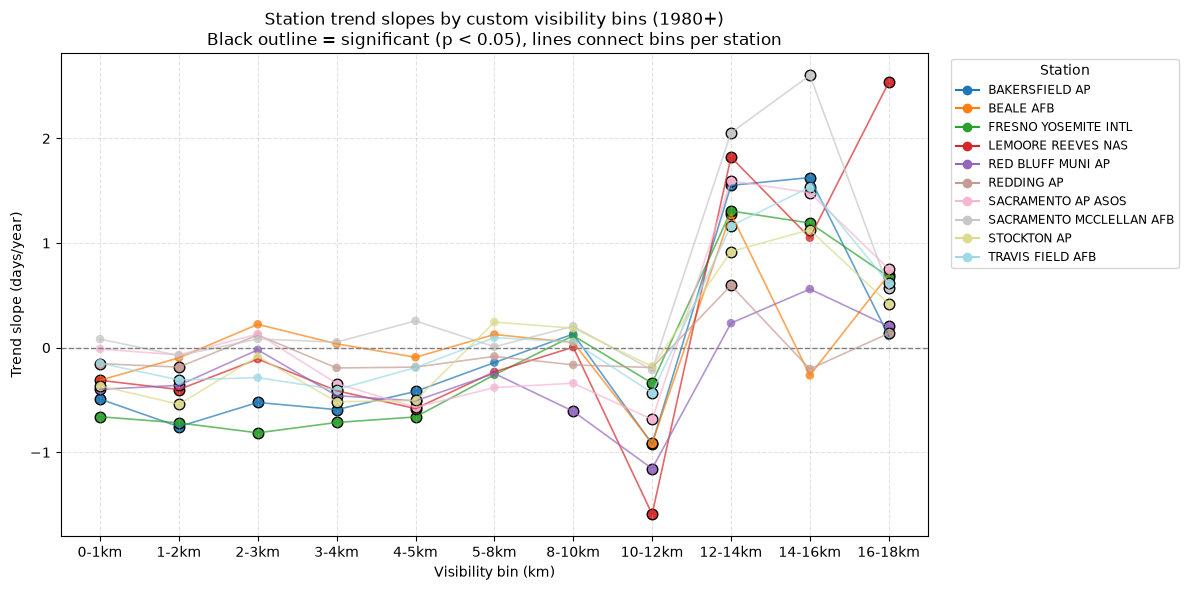

Significant trends: 60 / 110


In [30]:
# Same station-slope plot style, but with custom visibility bins:
# 5-8 km, 8-10 km, 10-12 km, 12-14 km (using 1980+ data)

p_cutoff = 0.05
custom_bins = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 8), (8, 10), (10, 12), (12, 14),(14, 16),(16, 18)]

if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

custom_bin_rows = []

for lo, hi in custom_bins:
    bin_df = base_df[
        (base_df["HourlyVisibility"] >= lo) & (base_df["HourlyVisibility"] < hi)
    ].copy()

    annual = (
        bin_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "filtered_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue

        model = smf.ols("filtered_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue

        custom_bin_rows.append({
            "bin_label": f"{lo}-{hi}km",
            "bin_lo": lo,
            "bin_hi": hi,
            "bin_mid": (lo + hi) / 2,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
        })

custom_bin_trends = pd.DataFrame(custom_bin_rows)

if custom_bin_trends.empty:
    print("No trends available for the requested bins.")
else:
    # Keep same station subset behavior as earlier plot if available
    if "selected_stations" in globals():
        stations_to_plot = [s for s in selected_stations if s in custom_bin_trends["STATION"].unique()]
    else:
        stations_to_plot = sorted(custom_bin_trends["STATION"].unique())

    plot_df = custom_bin_trends[custom_bin_trends["STATION"].isin(stations_to_plot)].copy()

    # Station colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(stations_to_plot)))
    station_color = dict(zip(stations_to_plot, colors))

    # X position map for categorical bins
    bin_order = [f"{lo}-{hi}km" for lo, hi in custom_bins]
    x_map = {label: i for i, label in enumerate(bin_order)}
    plot_df["x"] = plot_df["bin_label"].map(x_map)

    fig, ax = plt.subplots(figsize=(12, 6))

    for st in stations_to_plot:
        sdf = plot_df[plot_df["STATION"] == st].sort_values("x")
        if sdf.empty:
            continue

        color = station_color[st]

        # Connect bins
        ax.plot(sdf["x"], sdf["slope"], color=color, linewidth=1.2, alpha=0.7)

        # Non-significant points
        nonsig = sdf[~sdf["trend_significant"]]
        ax.scatter(
            nonsig["x"], nonsig["slope"],
            s=38, color=color, alpha=0.8, edgecolors="none"
        )

        # Significant points
        sig = sdf[sdf["trend_significant"]]
        ax.scatter(
            sig["x"], sig["slope"],
            s=58, color=color, alpha=0.95, edgecolors="black", linewidths=1.0
        )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order)
    ax.set_xlabel("Visibility bin (km)")
    ax.set_ylabel("Trend slope (days/year)")
    ax.set_title(
        "Station trend slopes by custom visibility bins (1980+)\n"
        "Black outline = significant (p < 0.05), lines connect bins per station"
    )
    ax.grid(True, linestyle="--", alpha=0.35)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="-", markersize=6,
                   color=station_color[st], label=st)
        for st in stations_to_plot
    ]
    ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

    plt.tight_layout()
    plt.show()

    print(f"Significant trends: {plot_df['trend_significant'].sum()} / {len(plot_df)}")

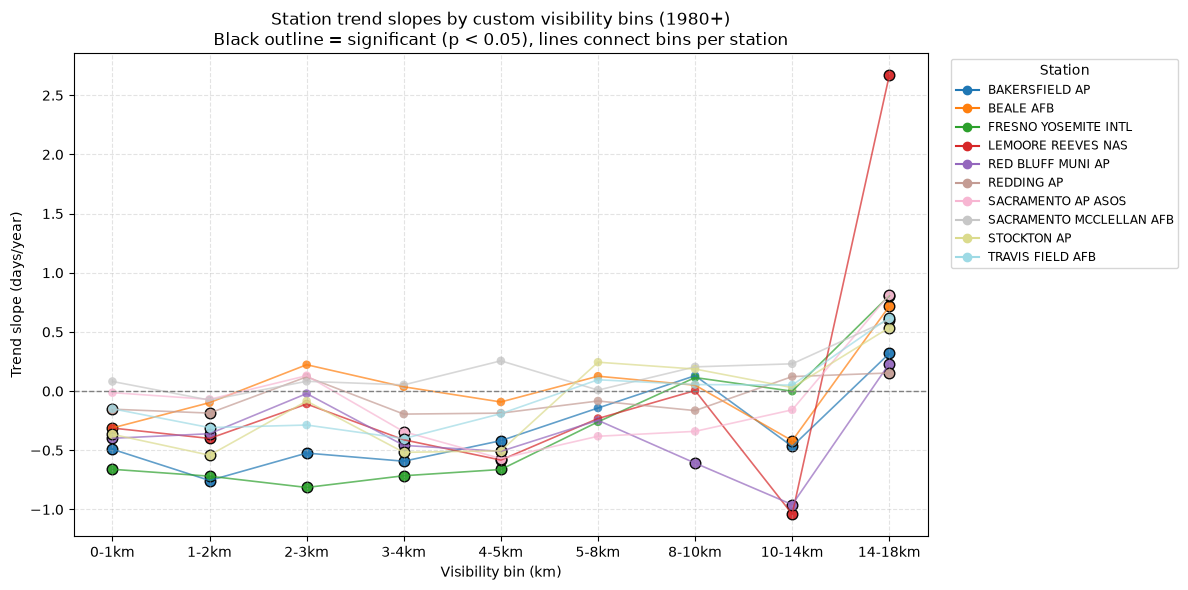

Significant trends: 43 / 90


In [31]:
# Same station-slope plot style, but with custom visibility bins:
# 5-8 km, 8-10 km, 10-12 km, 12-14 km (using 1980+ data)

p_cutoff = 0.05
custom_bins = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 8), (8, 10), (10, 14),(14, 18)]

if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

custom_bin_rows = []

for lo, hi in custom_bins:
    bin_df = base_df[
        (base_df["HourlyVisibility"] >= lo) & (base_df["HourlyVisibility"] < hi)
    ].copy()

    annual = (
        bin_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "filtered_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue

        model = smf.ols("filtered_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue

        custom_bin_rows.append({
            "bin_label": f"{lo}-{hi}km",
            "bin_lo": lo,
            "bin_hi": hi,
            "bin_mid": (lo + hi) / 2,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
        })

custom_bin_trends = pd.DataFrame(custom_bin_rows)

if custom_bin_trends.empty:
    print("No trends available for the requested bins.")
else:
    # Keep same station subset behavior as earlier plot if available
    if "selected_stations" in globals():
        stations_to_plot = [s for s in selected_stations if s in custom_bin_trends["STATION"].unique()]
    else:
        stations_to_plot = sorted(custom_bin_trends["STATION"].unique())

    plot_df = custom_bin_trends[custom_bin_trends["STATION"].isin(stations_to_plot)].copy()

    # Station colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(stations_to_plot)))
    station_color = dict(zip(stations_to_plot, colors))

    # X position map for categorical bins
    bin_order = [f"{lo}-{hi}km" for lo, hi in custom_bins]
    x_map = {label: i for i, label in enumerate(bin_order)}
    plot_df["x"] = plot_df["bin_label"].map(x_map)

    fig, ax = plt.subplots(figsize=(12, 6))

    for st in stations_to_plot:
        sdf = plot_df[plot_df["STATION"] == st].sort_values("x")
        if sdf.empty:
            continue

        color = station_color[st]

        # Connect bins
        ax.plot(sdf["x"], sdf["slope"], color=color, linewidth=1.2, alpha=0.7)

        # Non-significant points
        nonsig = sdf[~sdf["trend_significant"]]
        ax.scatter(
            nonsig["x"], nonsig["slope"],
            s=38, color=color, alpha=0.8, edgecolors="none"
        )

        # Significant points
        sig = sdf[sdf["trend_significant"]]
        ax.scatter(
            sig["x"], sig["slope"],
            s=58, color=color, alpha=0.95, edgecolors="black", linewidths=1.0
        )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order)
    ax.set_xlabel("Visibility bin (km)")
    ax.set_ylabel("Trend slope (days/year)")
    ax.set_title(
        "Station trend slopes by custom visibility bins (1980+)\n"
        "Black outline = significant (p < 0.05), lines connect bins per station"
    )
    ax.grid(True, linestyle="--", alpha=0.35)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="-", markersize=6,
                   color=station_color[st], label=st)
        for st in stations_to_plot
    ]
    ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

    plt.tight_layout()
    plt.show()

    print(f"Significant trends: {plot_df['trend_significant'].sum()} / {len(plot_df)}")

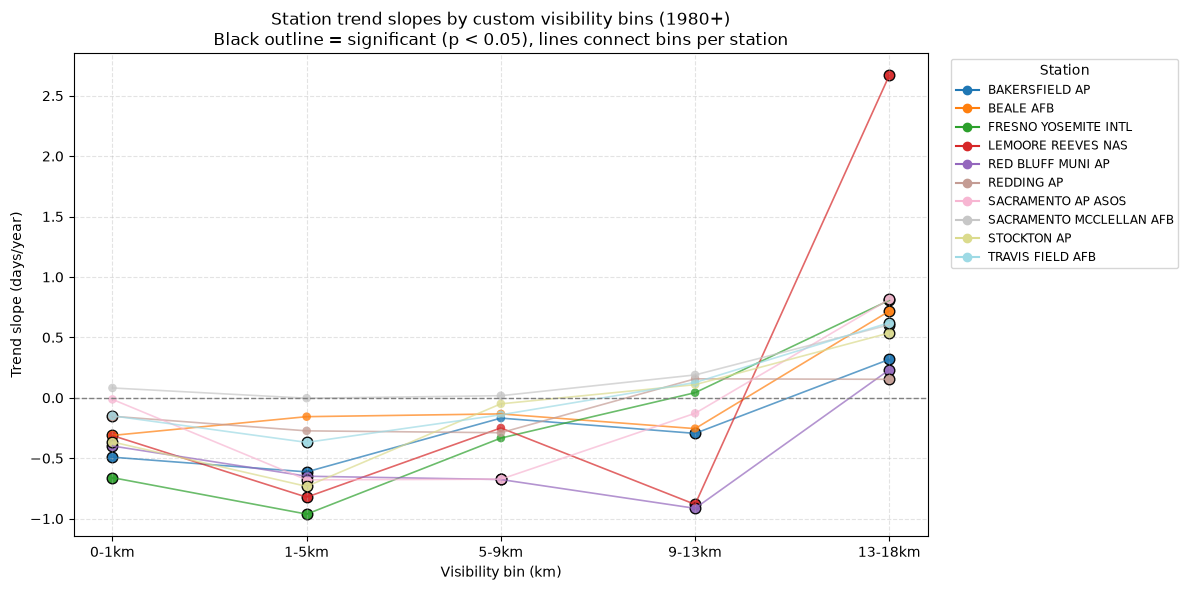

Significant trends: 28 / 50


In [32]:
# Same station-slope plot style, but with custom visibility bins:
# 5-8 km, 8-10 km, 10-12 km, 12-14 km (using 1980+ data)

p_cutoff = 0.05
custom_bins = [(0, 1), (1, 5), (5, 9), (9, 13), (13, 18)]

if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

custom_bin_rows = []

for lo, hi in custom_bins:
    bin_df = base_df[
        (base_df["HourlyVisibility"] >= lo) & (base_df["HourlyVisibility"] < hi)
    ].copy()

    annual = (
        bin_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "filtered_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue

        model = smf.ols("filtered_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue

        custom_bin_rows.append({
            "bin_label": f"{lo}-{hi}km",
            "bin_lo": lo,
            "bin_hi": hi,
            "bin_mid": (lo + hi) / 2,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
        })

custom_bin_trends = pd.DataFrame(custom_bin_rows)

if custom_bin_trends.empty:
    print("No trends available for the requested bins.")
else:
    # Keep same station subset behavior as earlier plot if available
    if "selected_stations" in globals():
        stations_to_plot = [s for s in selected_stations if s in custom_bin_trends["STATION"].unique()]
    else:
        stations_to_plot = sorted(custom_bin_trends["STATION"].unique())

    plot_df = custom_bin_trends[custom_bin_trends["STATION"].isin(stations_to_plot)].copy()

    # Station colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(stations_to_plot)))
    station_color = dict(zip(stations_to_plot, colors))

    # X position map for categorical bins
    bin_order = [f"{lo}-{hi}km" for lo, hi in custom_bins]
    x_map = {label: i for i, label in enumerate(bin_order)}
    plot_df["x"] = plot_df["bin_label"].map(x_map)

    fig, ax = plt.subplots(figsize=(12, 6))

    for st in stations_to_plot:
        sdf = plot_df[plot_df["STATION"] == st].sort_values("x")
        if sdf.empty:
            continue

        color = station_color[st]

        # Connect bins
        ax.plot(sdf["x"], sdf["slope"], color=color, linewidth=1.2, alpha=0.7)

        # Non-significant points
        nonsig = sdf[~sdf["trend_significant"]]
        ax.scatter(
            nonsig["x"], nonsig["slope"],
            s=38, color=color, alpha=0.8, edgecolors="none"
        )

        # Significant points
        sig = sdf[sdf["trend_significant"]]
        ax.scatter(
            sig["x"], sig["slope"],
            s=58, color=color, alpha=0.95, edgecolors="black", linewidths=1.0
        )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order)
    ax.set_xlabel("Visibility bin (km)")
    ax.set_ylabel("Trend slope (days/year)")
    ax.set_title(
        "Station trend slopes by custom visibility bins (1980+)\n"
        "Black outline = significant (p < 0.05), lines connect bins per station"
    )
    ax.grid(True, linestyle="--", alpha=0.35)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="-", markersize=6,
                   color=station_color[st], label=st)
        for st in stations_to_plot
    ]
    ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

    plt.tight_layout()
    plt.show()

    print(f"Significant trends: {plot_df['trend_significant'].sum()} / {len(plot_df)}")

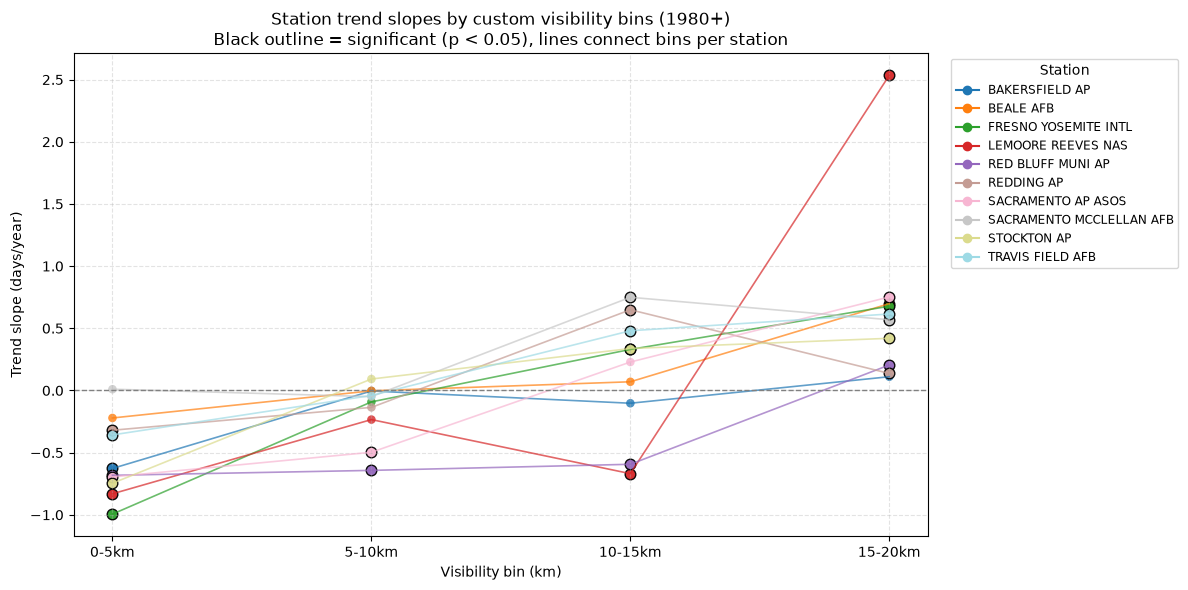

Significant trends: 26 / 40


In [33]:
# Same station-slope plot style, but with custom visibility bins:
# 5-8 km, 8-10 km, 10-12 km, 12-14 km (using 1980+ data)

p_cutoff = 0.05
custom_bins = [(0, 5), (5, 10), (10, 15), (15, 20)]

if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

custom_bin_rows = []

for lo, hi in custom_bins:
    bin_df = base_df[
        (base_df["HourlyVisibility"] >= lo) & (base_df["HourlyVisibility"] < hi)
    ].copy()

    annual = (
        bin_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "filtered_days"})
        .sort_values(["STATION", "year"])
    )

    for station, sdf in annual.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue

        model = smf.ols("filtered_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue

        custom_bin_rows.append({
            "bin_label": f"{lo}-{hi}km",
            "bin_lo": lo,
            "bin_hi": hi,
            "bin_mid": (lo + hi) / 2,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
        })

custom_bin_trends = pd.DataFrame(custom_bin_rows)

if custom_bin_trends.empty:
    print("No trends available for the requested bins.")
else:
    # Keep same station subset behavior as earlier plot if available
    if "selected_stations" in globals():
        stations_to_plot = [s for s in selected_stations if s in custom_bin_trends["STATION"].unique()]
    else:
        stations_to_plot = sorted(custom_bin_trends["STATION"].unique())

    plot_df = custom_bin_trends[custom_bin_trends["STATION"].isin(stations_to_plot)].copy()

    # Station colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(stations_to_plot)))
    station_color = dict(zip(stations_to_plot, colors))

    # X position map for categorical bins
    bin_order = [f"{lo}-{hi}km" for lo, hi in custom_bins]
    x_map = {label: i for i, label in enumerate(bin_order)}
    plot_df["x"] = plot_df["bin_label"].map(x_map)

    fig, ax = plt.subplots(figsize=(12, 6))

    for st in stations_to_plot:
        sdf = plot_df[plot_df["STATION"] == st].sort_values("x")
        if sdf.empty:
            continue

        color = station_color[st]

        # Connect bins
        ax.plot(sdf["x"], sdf["slope"], color=color, linewidth=1.2, alpha=0.7)

        # Non-significant points
        nonsig = sdf[~sdf["trend_significant"]]
        ax.scatter(
            nonsig["x"], nonsig["slope"],
            s=38, color=color, alpha=0.8, edgecolors="none"
        )

        # Significant points
        sig = sdf[sdf["trend_significant"]]
        ax.scatter(
            sig["x"], sig["slope"],
            s=58, color=color, alpha=0.95, edgecolors="black", linewidths=1.0
        )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order)
    ax.set_xlabel("Visibility bin (km)")
    ax.set_ylabel("Trend slope (days/year)")
    ax.set_title(
        "Station trend slopes by custom visibility bins (1980+)\n"
        "Black outline = significant (p < 0.05), lines connect bins per station"
    )
    ax.grid(True, linestyle="--", alpha=0.35)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="-", markersize=6,
                   color=station_color[st], label=st)
        for st in stations_to_plot
    ]
    ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

    plt.tight_layout()
    plt.show()

    print(f"Significant trends: {plot_df['trend_significant'].sum()} / {len(plot_df)}")

          STATION  year  observed_hours  expected_hours  coverage_percent
0  BAKERSFIELD AP  1980            3512            3648         96.271930
1  BAKERSFIELD AP  1981            3509            3624         96.826711
2  BAKERSFIELD AP  1982            3499            3624         96.550773
3  BAKERSFIELD AP  1983            3440            3624         94.922737
4  BAKERSFIELD AP  1984            3566            3648         97.752193
Station-year records: (822, 5)


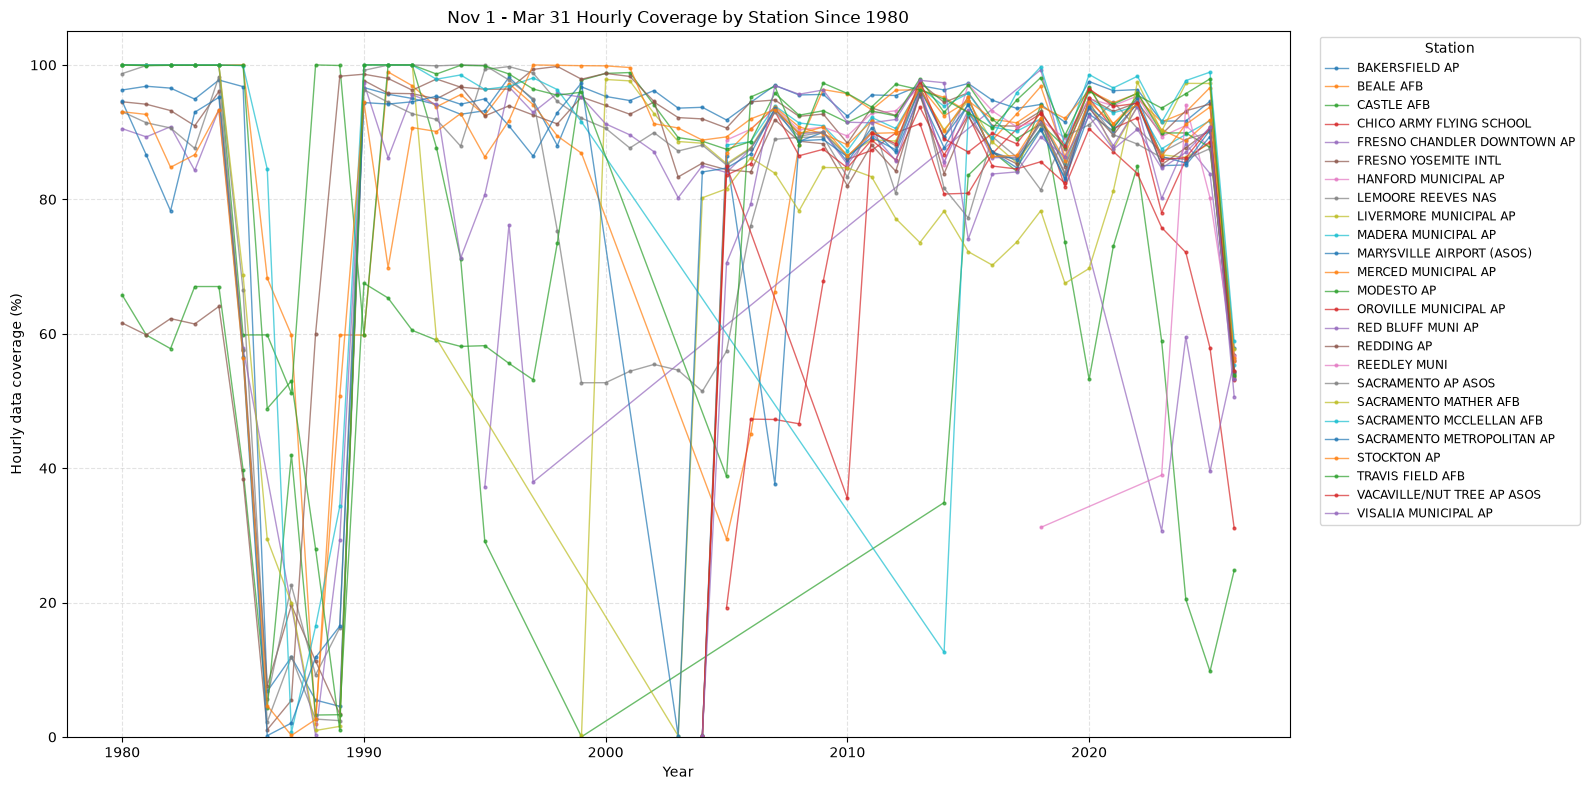

In [35]:
# Determine annual hourly coverage for each station since 1980

coverage_rows = CV_filtered_rows[CV_filtered_rows["year"] >= 1980].copy()
coverage_rows["DATE"] = pd.to_datetime(coverage_rows["DATE"], errors="coerce")
coverage_rows = coverage_rows.dropna(subset=["DATE", "STATION"])

# Count unique observed hours per station and year
coverage_rows["hour_timestamp"] = coverage_rows["DATE"].dt.floor("h")

observed_hours = (
    coverage_rows
    .drop_duplicates(subset=["STATION", "hour_timestamp"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "observed_hours"})
)

# Expected hours in each year, accounting for leap years where only the days from November 1 - March 31 are considered
observed_hours["expected_hours"] = np.where(
    observed_hours["year"].apply(lambda year: pd.Timestamp(year, 12, 31).is_leap_year),
    3648,
    3624
)

observed_hours["coverage_percent"] = (
    observed_hours["observed_hours"] /
    observed_hours["expected_hours"] * 100
)

hourly_coverage_year = observed_hours.sort_values(["STATION", "year"])

print(hourly_coverage_year.head())
print("Station-year records:", hourly_coverage_year.shape)

# Plot annual hourly coverage by station
fig, ax = plt.subplots(figsize=(16, 8))

for station, station_df in hourly_coverage_year.groupby("STATION"):
    ax.plot(
        station_df["year"],
        station_df["coverage_percent"],
        marker="o",
        markersize=2,
        linewidth=1,
        alpha=0.7,
        label=station
    )

ax.set_xlabel("Year")
ax.set_ylabel("Hourly data coverage (%)")
ax.set_title("Nov 1 - Mar 31 Hourly Coverage by Station Since 1980")
ax.set_ylim(0, 105)
ax.grid(True, linestyle="--", alpha=0.35)

ax.legend(
    title="Station",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize="small"
)

plt.tight_layout()
plt.show()

          STATION  year  observed_hours  expected_hours  coverage_percent
0  BAKERSFIELD AP  1980            8782            8784         99.977231
1  BAKERSFIELD AP  1981            8758            8760         99.977169
2  BAKERSFIELD AP  1982            8755            8760         99.942922
3  BAKERSFIELD AP  1983            8747            8760         99.851598
4  BAKERSFIELD AP  1984            8745            8784         99.556011
Station-year records: (823, 5)


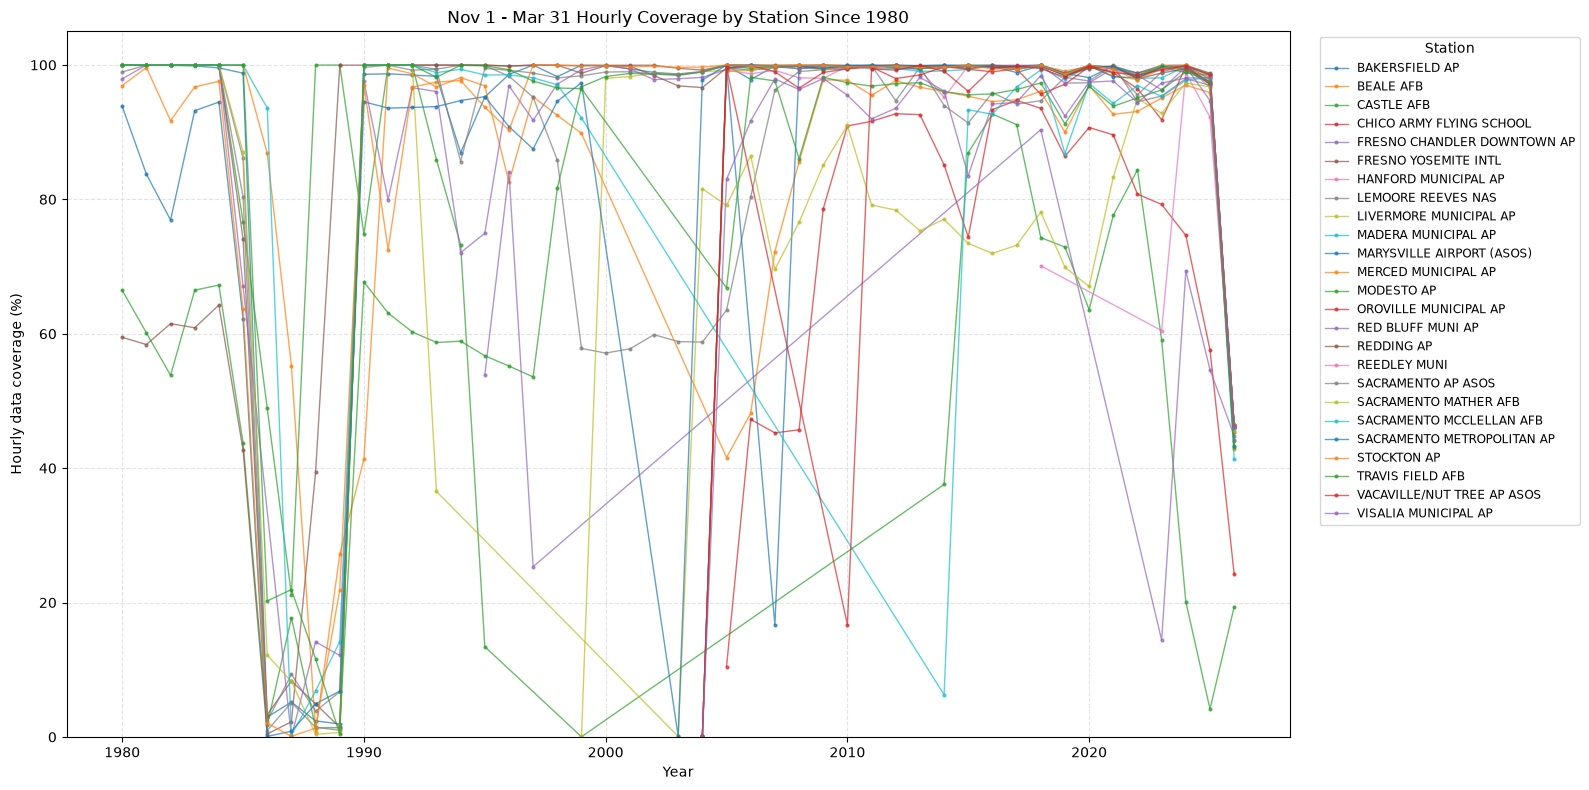

In [36]:
# Determine annual hourly coverage for each station since 1980

coverage_rows = CV_rows[CV_rows["year"] >= 1980].copy()
coverage_rows["DATE"] = pd.to_datetime(coverage_rows["DATE"], errors="coerce")
coverage_rows = coverage_rows.dropna(subset=["DATE", "STATION"])

# Count unique observed hours per station and year
coverage_rows["hour_timestamp"] = coverage_rows["DATE"].dt.floor("h")

observed_hours = (
    coverage_rows
    .drop_duplicates(subset=["STATION", "hour_timestamp"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "observed_hours"})
)

# Expected hours in each year, accounting for leap years
observed_hours["expected_hours"] = np.where(
    observed_hours["year"].apply(lambda year: pd.Timestamp(year, 12, 31).is_leap_year),
    8784,
    8760
)

observed_hours["coverage_percent"] = (
    observed_hours["observed_hours"] /
    observed_hours["expected_hours"] * 100
)

hourly_coverage_year = observed_hours.sort_values(["STATION", "year"])

print(hourly_coverage_year.head())
print("Station-year records:", hourly_coverage_year.shape)

# Plot annual hourly coverage by station
fig, ax = plt.subplots(figsize=(16, 8))

for station, station_df in hourly_coverage_year.groupby("STATION"):
    ax.plot(
        station_df["year"],
        station_df["coverage_percent"],
        marker="o",
        markersize=2,
        linewidth=1,
        alpha=0.7,
        label=station
    )

ax.set_xlabel("Year")
ax.set_ylabel("Hourly data coverage (%)")
ax.set_title("Nov 1 - Mar 31 Hourly Coverage by Station Since 1980")
ax.set_ylim(0, 105)
ax.grid(True, linestyle="--", alpha=0.35)

ax.legend(
    title="Station",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize="small"
)

plt.tight_layout()
plt.show()

In [38]:
# Assess whether the <1 km fog-day trend is driven by station coverage
# Use the same annual window as the trend analysis (1980+; winter-only filtered data)
if "df_1980" in globals():
    base_df = df_1980.copy()
else:
    base_df = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 1980].copy()

# 1) Annual fog days for visibility < 1 km
annual_lt1 = (
    base_df[base_df["HourlyVisibility"] < 1]
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
    .sort_values(["STATION", "year"])
)

# 2) Annual station coverage in the same filtered window
coverage_rows = base_df.copy()
coverage_rows["DATE"] = pd.to_datetime(coverage_rows["DATE"], errors="coerce")
coverage_rows = coverage_rows.dropna(subset=["DATE", "STATION"])
coverage_rows["hour_timestamp"] = coverage_rows["DATE"].dt.floor("h")

annual_coverage = (
    coverage_rows
    .drop_duplicates(subset=["STATION", "hour_timestamp"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "observed_hours"})
)

annual_coverage["expected_hours"] = np.where(
    annual_coverage["year"].apply(lambda y: pd.Timestamp(y, 12, 31).is_leap_year),
    3648,
    3624
)
annual_coverage["coverage_percent"] = (
    annual_coverage["observed_hours"] / annual_coverage["expected_hours"] * 100
)

# Merge fog days and coverage
annual_lt1_cov = annual_lt1.merge(annual_coverage, on=["STATION", "year"], how="left")
annual_lt1_cov["coverage_percent"] = annual_lt1_cov["coverage_percent"].fillna(0)

# 3) Check whether fog days are associated with coverage at the station-year level
corr_year = annual_lt1_cov[["fog_days", "coverage_percent"]].corr().loc["fog_days", "coverage_percent"]
print(f"Correlation between fog_days and annual coverage (%): {corr_year:.4f}")

# 4) Compare original <1 km station trends with station-level mean coverage and coverage trend
station_lt1 = (
    threshold_trends_1980[threshold_trends_1980["threshold_km"] == 1]
    .loc[:, ["STATION", "slope", "p_value", "trend_significant"]]
    .copy()
)

station_cov_summary = (
    annual_lt1_cov
    .groupby("STATION", as_index=False)
    .agg(
        mean_coverage=("coverage_percent", "mean"),
        min_coverage=("coverage_percent", "min"),
        max_coverage=("coverage_percent", "max"),
        median_coverage=("coverage_percent", "median"),
    )
)

# Station coverage trend (slope of coverage_percent vs year)
coverage_trend_rows = []
for station, sdf in annual_lt1_cov.groupby("STATION", sort=False):
    sdf = sdf.sort_values("year")
    if len(sdf) < 3:
        continue
    model = smf.ols("coverage_percent ~ year", data=sdf).fit()
    pval = float(model.pvalues.get("year", np.nan))
    if np.isnan(pval):
        continue
    coverage_trend_rows.append({
        "STATION": station,
        "coverage_trend_slope": float(model.params.get("year", np.nan)),
        "coverage_r2": float(model.rsquared),
        "coverage_p_value": pval
    })

coverage_trend = pd.DataFrame(coverage_trend_rows)

station_compare = station_lt1.merge(station_cov_summary, on="STATION", how="left")
station_compare = station_compare.merge(coverage_trend, on="STATION", how="left")
station_compare = station_compare.sort_values("slope")

print("\nStation-level relationship between <1 km trend slope and coverage:")
print(station_compare[["STATION", "slope", "mean_coverage", "coverage_trend_slope"]].head(20).to_string(index=False))

print(f"\nCorrelation between station trend slope and mean coverage: {station_compare['slope'].corr(station_compare['mean_coverage']):.4f}")
print(f"Correlation between station trend slope and coverage trend slope: {station_compare['slope'].corr(station_compare['coverage_trend_slope']):.4f}")

# 5) Robustness check: repeat slopes using only years with >=80% station coverage
high_cov = annual_lt1_cov[annual_lt1_cov["coverage_percent"] >= 80].copy()
results_high_cov = []
for station, sdf in high_cov.groupby("STATION", sort=False):
    sdf = sdf.sort_values("year")
    if len(sdf) < 3:
        continue
    model = smf.ols("fog_days ~ year", data=sdf).fit()
    pval = float(model.pvalues.get("year", np.nan))
    if np.isnan(pval):
        continue
    results_high_cov.append({
        "STATION": station,
        "slope_high_cov": float(model.params.get("year", np.nan)),
        "p_value_high_cov": pval,
        "n_obs_high_cov": len(sdf)
    })

high_cov_df = pd.DataFrame(results_high_cov)
compare_high = station_lt1[["STATION", "slope"]].merge(high_cov_df, on="STATION", how="left")
compare_high["delta_slope"] = compare_high["slope_high_cov"] - compare_high["slope"]
compare_high["abs_delta_slope"] = compare_high["delta_slope"].abs()
compare_high = compare_high.dropna(subset=["slope_high_cov"]).sort_values("abs_delta_slope", ascending=False)

print("\nChange in station <1 km slope when requiring >=80% coverage each year:")
print(compare_high[["STATION", "slope", "slope_high_cov", "delta_slope"]].head(20).to_string(index=False))

# 6) Quick interpretation
print("\nInterpretation:")
print("- If fog-day trends are coverage-driven, we expect strong correlation between annual fog_days and annual coverage,")
print("  or a strong relationship between slope and station mean/coverage trend.")
print("- If slopes remain similar after excluding low-coverage years, then coverage is probably not the main driver.")
print("- If low-coverage years are concentrated in the same stations that show strong negative slopes, coverage may be inflating or masking the trend.")

Correlation between fog_days and annual coverage (%): 0.1340

Station-level relationship between <1 km trend slope and coverage:
                   STATION     slope  mean_coverage  coverage_trend_slope
      HANFORD MUNICIPAL AP -1.088080      91.993153              0.097738
 MARYSVILLE AIRPORT (ASOS) -0.968735      88.628408             -0.074076
      FRESNO YOSEMITE INTL -0.660703      93.400871             -0.050323
            BAKERSFIELD AP -0.491368      95.106963             -0.042096
         RED BLUFF MUNI AP -0.398781      89.804711             -0.005572
       MERCED MUNICIPAL AP -0.383117      91.994032              0.143647
               STOCKTON AP -0.365192      91.421631             -0.009477
        LEMOORE REEVES NAS -0.312306      94.766183             -0.316099
                 BEALE AFB -0.311273      96.810473             -0.134874
                MODESTO AP -0.204038      82.094530              0.930467
SACRAMENTO METROPOLITAN AP -0.192138      90.275519      

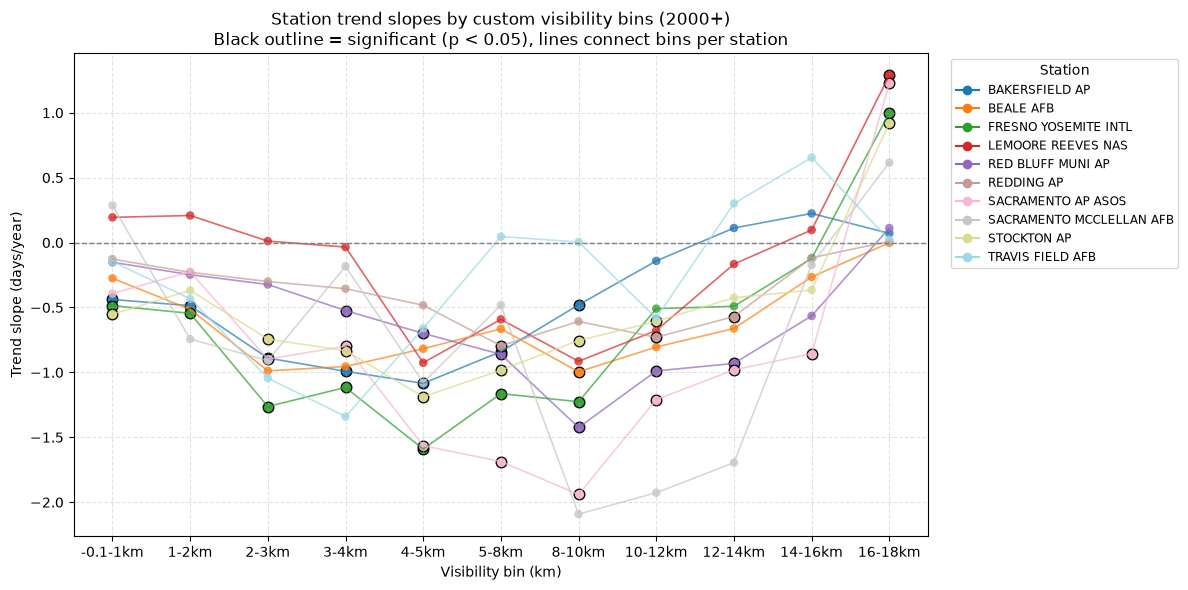

Significant trends (2000+): 43 / 110
bin_label              STATION  n_obs     slope      p_value  r_squared
 -0.1-1km          STOCKTON AP     26 -0.551795 2.004394e-02   0.205454
 -0.1-1km       BAKERSFIELD AP     26 -0.438291 2.175811e-02   0.200608
 -0.1-1km FRESNO YOSEMITE INTL     26 -0.485812 2.993123e-02   0.181635
    1-2km       BAKERSFIELD AP     26 -0.486154 1.432883e-02   0.225104
    1-2km FRESNO YOSEMITE INTL     26 -0.545299 3.362782e-02   0.174657
  10-12km   SACRAMENTO AP ASOS     22 -1.209439 1.097738e-05   0.628075
  10-12km    RED BLUFF MUNI AP     20 -0.988592 5.624369e-03   0.354336
  10-12km          STOCKTON AP     26 -0.607179 6.000874e-03   0.274594
  10-12km           REDDING AP     26 -0.729915 3.327513e-02   0.175290
  12-14km   SACRAMENTO AP ASOS     22 -0.980487 3.277355e-04   0.483481
  12-14km    RED BLUFF MUNI AP     20 -0.930870 1.070767e-02   0.310441
  12-14km           REDDING AP     26 -0.569573 3.513801e-02   0.172019
  14-16km   SACRAMENTO AP A

In [39]:
# Same custom-bin station-slope plot, but restricted to years >= 2000

# Make custom bins and compute trends for years >= 2000
p_cutoff = 0.05
custom_bins = [(-0.1, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 8), (8, 10), (10, 12), (12, 14), (14, 16), (16, 18)]

# Base data for years >= 2000
base_df_2000 = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 2000].copy()

# This will be a smaller dataset, so fewer stations may have enough data for trend analysis.
custom_bin_rows_2000 = []
for lo, hi in custom_bins:
    bin_df = base_df_2000[
        (base_df_2000["HourlyVisibility"] >= lo) & (base_df_2000["HourlyVisibility"] < hi)
    ].copy()
# determine annual fog days per station for this bin
    annual = (
        bin_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "filtered_days"})
        .sort_values(["STATION", "year"])
    )
# compute trend for each station in this bin
    for station, sdf in annual.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue
# compute linear regression of filtered_days vs year
        model = smf.ols("filtered_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue
# store results for this station and bin
        custom_bin_rows_2000.append({
            "bin_label": f"{lo}-{hi}km",
            "bin_lo": lo,
            "bin_hi": hi,
            "bin_mid": (lo + hi) / 2,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
        })
# create DataFrame for trends in years >= 2000
custom_bin_trends_2000 = pd.DataFrame(custom_bin_rows_2000)
# if no trends are available for years >= 2000, print a message
if custom_bin_trends_2000.empty:
    print("No trends available for years >= 2000.")
else:
    # Keep same station subset if available
    if "stations_to_plot" in globals():
        stations_for_plot = [s for s in stations_to_plot if s in custom_bin_trends_2000["STATION"].unique()]
    else:
        stations_for_plot = sorted(custom_bin_trends_2000["STATION"].unique())

    plot_df_2000 = custom_bin_trends_2000[
        custom_bin_trends_2000["STATION"].isin(stations_for_plot)
    ].copy()

    # X positions
    bin_order = [f"{lo}-{hi}km" for lo, hi in custom_bins]
    x_map_2000 = {label: i for i, label in enumerate(bin_order)}
    plot_df_2000["x"] = plot_df_2000["bin_label"].map(x_map_2000)

    # Colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_plot)))
    station_color_2000 = dict(zip(stations_for_plot, colors))

    fig, ax = plt.subplots(figsize=(12, 6))

    for st in stations_for_plot:
        sdf = plot_df_2000[plot_df_2000["STATION"] == st].sort_values("x")
        if sdf.empty:
            continue

        color = station_color_2000[st]
        ax.plot(sdf["x"], sdf["slope"], color=color, linewidth=1.2, alpha=0.7)

        nonsig = sdf[~sdf["trend_significant"]]
        ax.scatter(nonsig["x"], nonsig["slope"], s=38, color=color, alpha=0.8, edgecolors="none")

        sig = sdf[sdf["trend_significant"]]
        ax.scatter(sig["x"], sig["slope"], s=58, color=color, alpha=0.95, edgecolors="black", linewidths=1.0)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order)
    ax.set_xlabel("Visibility bin (km)")
    ax.set_ylabel("Trend slope (days/year)")
    ax.set_title(
        "Station trend slopes by custom visibility bins (2000+)\n"
        "Black outline = significant (p < 0.05), lines connect bins per station"
    )
    ax.grid(True, linestyle="--", alpha=0.35)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="-", markersize=6,
                   color=station_color_2000[st], label=st)
        for st in stations_for_plot
    ]
    ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

    plt.tight_layout()
    plt.show()

    print(f"Significant trends (2000+): {plot_df_2000['trend_significant'].sum()} / {len(plot_df_2000)}")
    print(
        plot_df_2000.loc[plot_df_2000["trend_significant"],
                         ["bin_label", "STATION", "n_obs", "slope", "p_value", "r_squared"]]
        .sort_values(["bin_label", "p_value"])
        .to_string(index=False)
    )

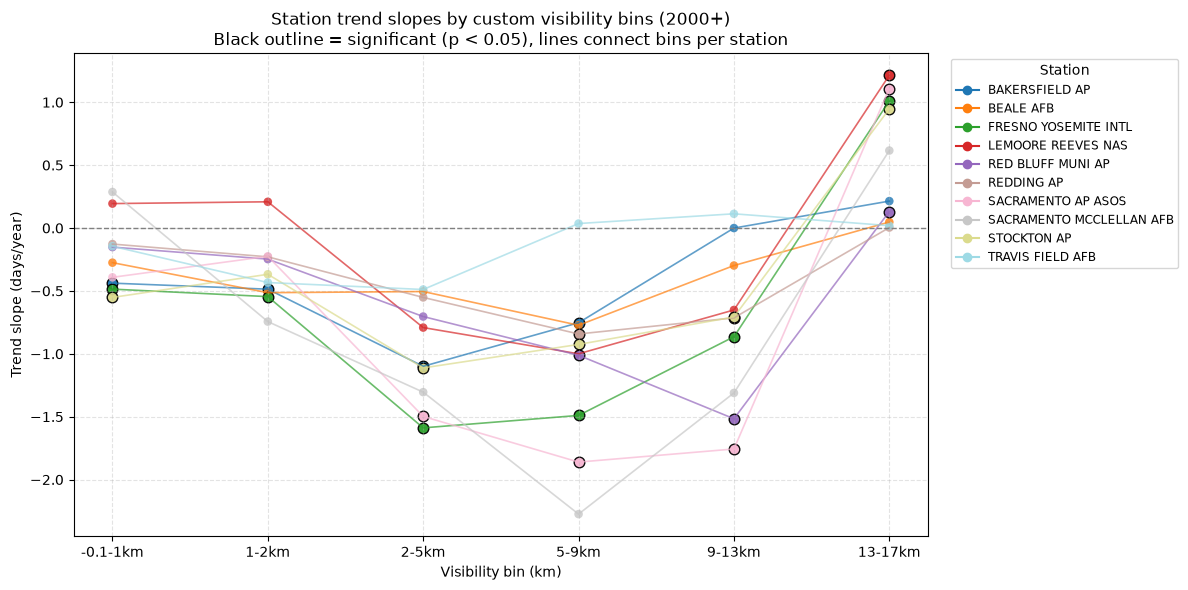

Significant trends (2000+): 25 / 60
bin_label              STATION  n_obs     slope      p_value  r_squared
 -0.1-1km          STOCKTON AP     26 -0.551795 2.004394e-02   0.205454
 -0.1-1km       BAKERSFIELD AP     26 -0.438291 2.175811e-02   0.200608
 -0.1-1km FRESNO YOSEMITE INTL     26 -0.485812 2.993123e-02   0.181635
    1-2km       BAKERSFIELD AP     26 -0.486154 1.432883e-02   0.225104
    1-2km FRESNO YOSEMITE INTL     26 -0.545299 3.362782e-02   0.174657
  13-17km   SACRAMENTO AP ASOS     22  1.109122 1.185869e-04   0.531527
  13-17km FRESNO YOSEMITE INTL     26  1.010598 2.353905e-04   0.437196
  13-17km          STOCKTON AP     26  0.947009 3.100290e-04   0.424722
  13-17km   LEMOORE REEVES NAS     11  1.214286 2.469317e-02   0.446148
  13-17km    RED BLUFF MUNI AP     20  0.130938 3.679533e-02   0.220331
    2-5km FRESNO YOSEMITE INTL     26 -1.588718 2.405113e-07   0.677830
    2-5km          STOCKTON AP     26 -1.112137 7.541389e-05   0.486175
    2-5km       BAKERSFIELD 

In [40]:
# Same custom-bin station-slope plot, but restricted to years >= 2000

# Make custom bins and compute trends for years >= 2000
p_cutoff = 0.05
custom_bins = [(-0.1, 1), (1, 2), (2, 5), (5, 9), (9, 13), (13, 17)]

# Base data for years >= 2000
base_df_2000 = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["year"] >= 2000].copy()

# This will be a smaller dataset, so fewer stations may have enough data for trend analysis.
custom_bin_rows_2000 = []
for lo, hi in custom_bins:
    bin_df = base_df_2000[
        (base_df_2000["HourlyVisibility"] >= lo) & (base_df_2000["HourlyVisibility"] < hi)
    ].copy()
# determine annual fog days per station for this bin
    annual = (
        bin_df
        .drop_duplicates(subset=["STATION", "year", "month", "day"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "filtered_days"})
        .sort_values(["STATION", "year"])
    )
# compute trend for each station in this bin
    for station, sdf in annual.groupby("STATION", sort=False):
        sdf = sdf.sort_values("year")
        if len(sdf) < 3:
            continue
# compute linear regression of fog_days vs year
        model = smf.ols("filtered_days ~ year", data=sdf).fit()
        pval = float(model.pvalues.get("year", np.nan))
        if np.isnan(pval):
            continue
# store results for this station and bin
        custom_bin_rows_2000.append({
            "bin_label": f"{lo}-{hi}km",
            "bin_lo": lo,
            "bin_hi": hi,
            "bin_mid": (lo + hi) / 2,
            "STATION": station,
            "n_obs": len(sdf),
            "min_year": int(sdf["year"].min()),
            "max_year": int(sdf["year"].max()),
            "slope": float(model.params.get("year", np.nan)),
            "intercept": float(model.params.get("Intercept", np.nan)),
            "r_squared": float(model.rsquared),
            "p_value": pval,
            "trend_significant": pval < p_cutoff,
        })
# create DataFrame for trends in years >= 2000
custom_bin_trends_2000 = pd.DataFrame(custom_bin_rows_2000)
# if no trends are available for years >= 2000, print a message
if custom_bin_trends_2000.empty:
    print("No trends available for years >= 2000.")
else:
    # Keep same station subset if available
    if "stations_to_plot" in globals():
        stations_for_plot = [s for s in stations_to_plot if s in custom_bin_trends_2000["STATION"].unique()]
    else:
        stations_for_plot = sorted(custom_bin_trends_2000["STATION"].unique())

    plot_df_2000 = custom_bin_trends_2000[
        custom_bin_trends_2000["STATION"].isin(stations_for_plot)
    ].copy()

    # X positions
    bin_order = [f"{lo}-{hi}km" for lo, hi in custom_bins]
    x_map_2000 = {label: i for i, label in enumerate(bin_order)}
    plot_df_2000["x"] = plot_df_2000["bin_label"].map(x_map_2000)

    # Colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(stations_for_plot)))
    station_color_2000 = dict(zip(stations_for_plot, colors))

    fig, ax = plt.subplots(figsize=(12, 6))

    for st in stations_for_plot:
        sdf = plot_df_2000[plot_df_2000["STATION"] == st].sort_values("x")
        if sdf.empty:
            continue

        color = station_color_2000[st]
        ax.plot(sdf["x"], sdf["slope"], color=color, linewidth=1.2, alpha=0.7)

        nonsig = sdf[~sdf["trend_significant"]]
        ax.scatter(nonsig["x"], nonsig["slope"], s=38, color=color, alpha=0.8, edgecolors="none")

        sig = sdf[sdf["trend_significant"]]
        ax.scatter(sig["x"], sig["slope"], s=58, color=color, alpha=0.95, edgecolors="black", linewidths=1.0)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order)
    ax.set_xlabel("Visibility bin (km)")
    ax.set_ylabel("Trend slope (days/year)")
    ax.set_title(
        "Station trend slopes by custom visibility bins (2000+)\n"
        "Black outline = significant (p < 0.05), lines connect bins per station"
    )
    ax.grid(True, linestyle="--", alpha=0.35)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="-", markersize=6,
                   color=station_color_2000[st], label=st)
        for st in stations_for_plot
    ]
    ax.legend(handles=handles, title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

    plt.tight_layout()
    plt.show()

    print(f"Significant trends (2000+): {plot_df_2000['trend_significant'].sum()} / {len(plot_df_2000)}")
    print(
        plot_df_2000.loc[plot_df_2000["trend_significant"],
                         ["bin_label", "STATION", "n_obs", "slope", "p_value", "r_squared"]]
        .sort_values(["bin_label", "p_value"])
        .to_string(index=False)
    )

In [45]:
# Percentage of HourlyVisibility readings equal to 16 km by station and time period
vis_series = pd.to_numeric(CV_rows["HourlyVisibility"], errors="coerce")

period_df = CV_rows.copy()
period_df["HourlyVisibility"] = vis_series
period_df["period"] = np.select(
    [
        period_df["year"] < 1980,
        (period_df["year"] >= 1980) & (period_df["year"] < 2000),
        (period_df["year"] >= 2000) & (period_df["year"] < 2020),
        period_df["year"] >= 2020
    ],
    ["pre_1980", "1980_2000", "2000_to_2020", "post-2020"],
    default="other"
)

# Count total measurements and exact 16 km values per station-period
station_period = (
    period_df.groupby(["STATION", "period"], as_index=False)
    .agg(
        total_measurements=("HourlyVisibility", "size"),
        n_16_km=("HourlyVisibility", lambda s: np.isclose(s.to_numpy(), 16.0, rtol=0, atol=1e-9).sum())
    )
)

station_period["pct_16_km"] = (
    station_period["n_16_km"] / station_period["total_measurements"] * 100.0
)

# Make it easy to read as a station-by-period table
station_period_pct = (
    station_period
    .pivot(index="STATION", columns="period", values="pct_16_km")
    .reindex(["pre_1980", "1980_2000", "2000_to_2020", "post-2020"], axis=1)
    .sort_index()
)

station_period_pct = station_period_pct.round(4)

print("Percent of HourlyVisibility measurements equal to 16 km by station and period:")
display(station_period_pct)

# Optional long-form table for all counts and percentages
station_period_summary = station_period[
    ["STATION", "period", "total_measurements", "n_16_km", "pct_16_km"]
].sort_values(["STATION", "period"]).copy()

station_period_summary["pct_16_km"] = station_period_summary["pct_16_km"].round(4)
display(station_period_summary)

Percent of HourlyVisibility measurements equal to 16 km by station and period:


period,pre_1980,1980_2000,2000_to_2020,post-2020
STATION,,,,
BAKERSFIELD AP,7.2910,23.0708,16.8278,3.9095
BEALE AFB,16.8873,16.6802,0.0000,0.0000
CASTLE AFB,19.5478,16.0801,0.0000,0.0000
CHICO ARMY FLYING SCHOOL,NaN,NaN,0.0000,0.0000
FRESNO,0.0000,NaN,NaN,NaN
FRESNO CHANDLER DOWNTOWN AP,9.7229,0.0000,0.0000,0.0000
FRESNO YOSEMITE INTL,7.4646,25.2697,17.6117,8.6243
GARDNER AAF,5.3489,NaN,NaN,NaN
HAMMER AAF,5.7281,NaN,NaN,NaN


,STATION,period,total_measurements,n_16_km,pct_16_km
0,BAKERSFIELD AP,1980_2000,148287,34211,23.0708
1,BAKERSFIELD AP,2000_to_2020,202635,34099,16.8278
2,BAKERSFIELD AP,post-2020,65763,2571,3.9095
3,BAKERSFIELD AP,pre_1980,388218,28305,7.2910
4,BEALE AFB,1980_2000,154363,25748,16.6802
5,BEALE AFB,2000_to_2020,160599,0,0.0000
6,BEALE AFB,post-2020,68258,0,0.0000
7,BEALE AFB,pre_1980,128872,21763,16.8873
8,CASTLE AFB,1980_2000,121162,19483,16.0801
9,CASTLE AFB,2000_to_2020,70394,0,0.0000


In [46]:
# Do not display all rows of the summary table if it is very large
if len(station_period_summary) > 100:
    print(f"Summary table has {len(station_period_summary)} rows; displaying first 100 rows only.")
    display(station_period_summary.head(100))
else:
    display(station_period_summary) 

,STATION,period,total_measurements,n_16_km,pct_16_km
0,BAKERSFIELD AP,1980_2000,148287,34211,23.0708
1,BAKERSFIELD AP,2000_to_2020,202635,34099,16.8278
2,BAKERSFIELD AP,post-2020,65763,2571,3.9095
3,BAKERSFIELD AP,pre_1980,388218,28305,7.2910
4,BEALE AFB,1980_2000,154363,25748,16.6802
5,BEALE AFB,2000_to_2020,160599,0,0.0000
6,BEALE AFB,post-2020,68258,0,0.0000
7,BEALE AFB,pre_1980,128872,21763,16.8873
8,CASTLE AFB,1980_2000,121162,19483,16.0801
9,CASTLE AFB,2000_to_2020,70394,0,0.0000


In [44]:
# Display all rows of station_period_summary
pd.set_option("display.max_rows", None)
display(station_period_summary)

,STATION,period,total_measurements,n_16_km,pct_16_km
0,BAKERSFIELD AP,1980_2000,148287,34211,23.0708
1,BAKERSFIELD AP,2000_to_2020,202635,34099,16.8278
2,BAKERSFIELD AP,other,65763,2571,3.9095
3,BAKERSFIELD AP,pre_1980,388218,28305,7.2910
4,BEALE AFB,1980_2000,154363,25748,16.6802
5,BEALE AFB,2000_to_2020,160599,0,0.0000
6,BEALE AFB,other,68258,0,0.0000
7,BEALE AFB,pre_1980,128872,21763,16.8873
8,CASTLE AFB,1980_2000,121162,19483,16.0801
9,CASTLE AFB,2000_to_2020,70394,0,0.0000
